In [1]:
from config import config
from src.data import load_data
import matplotlib.pyplot as plt

train_df, test_df = load_data(config)

print('Train:', train_df.shape)
print('Test:', test_df.shape)

assert train_df.shape == (1460, 81)
assert test_df.shape == (1459, 80)

assert 'SalePrice' in train_df.columns
assert 'SalePrice' not in test_df.columns

assert train_df['Id'].is_unique
assert test_df['Id'].is_unique

assert train_df['SalePrice'].notna().all()
assert (train_df['SalePrice'] > 0).all()

print(train_df['MasVnrType'].value_counts(dropna=False))

Train: (1460, 81)
Test: (1459, 80)
MasVnrType
None       864
BrkFace    445
Stone      128
BrkCmn      15
NaN          8
Name: count, dtype: int64


In [2]:
from src.data import load_data, split_train_holdout

train_df, _ = load_data(config)
train_cv_df, holdout_df = split_train_holdout(train_df, config)

eda_outlier_ids = {524, 1299}
train_cv_ids = set(train_cv_df['Id'])
holdout_ids = set(holdout_df['Id'])

# Проверяем, что заданные дома удалены из Train/CV и не попали в holdout.
assert eda_outlier_ids.isdisjoint(train_cv_ids)
assert eda_outlier_ids.isdisjoint(holdout_ids)

# Проверяем, что Train/CV и holdout не пересекаются.
assert train_cv_ids.isdisjoint(holdout_ids)

# Два удалённых дома объясняют разницу с размером исходного датасета.
assert len(train_cv_df) + len(holdout_df) + len(eda_outlier_ids) == len(train_df)

print('Full train:', train_df.shape)
print('Train/CV:', train_cv_df.shape)
print('Holdout:', holdout_df.shape)

Removed EDA outliers: [524, 1299] (1168 -> 1166)
Full train: (1460, 81)
Train/CV: (1166, 81)
Holdout: (292, 81)


In [3]:
import pandas as pd
from config import config

# Старый вариант
train_old = pd.read_csv(config.paths.path_to_csv)

# Новый вариант
train_new = pd.read_csv(
    config.paths.path_to_csv,
    keep_default_na=False,
    na_values=['', 'NA'],
)

comparison = pd.concat(
    [
        train_old['MasVnrType'].value_counts(dropna=False),
        train_new['MasVnrType'].value_counts(dropna=False),
    ],
    axis=1,
    keys=['Старое чтение', 'Новое чтение'],
).fillna(0).astype(int)

comparison

,Старое чтение,Новое чтение
MasVnrType,,
NaN,872,8
BrkFace,445,445
Stone,128,128
BrkCmn,15,15
None,0,864


In [4]:
train_df.loc[train_df['MasVnrType'].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
234,235,60,RL,NaN,7851,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,216500
529,530,20,RL,NaN,32668,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Alloca,200624
650,651,60,FV,65.0,8125,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,205950
936,937,20,RL,67.0,10083,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,WD,Normal,184900
973,974,20,FV,95.0,11639,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,New,Partial,182000
977,978,120,FV,35.0,4274,Pave,Pave,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,New,Partial,199900
1243,1244,20,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2006,New,Partial,465000
1278,1279,60,RL,75.0,9473,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2008,WD,Normal,237000


In [5]:
import numpy as np

X = train_df.drop(columns=['Id', 'SalePrice']).copy()
y = np.log(train_df['SalePrice'])

X_test = test_df.drop(columns=['Id']).copy()

In [6]:
numerical_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

print('Числовых:', len(numerical_cols))
print('Категориальных:', len(categorical_cols))

print('Числовые признаки:')
print(numerical_cols)

Числовых: 35
Категориальных: 44
Числовые признаки:
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


## CatBoost — Optuna

In [1]:
import importlib
from copy import deepcopy
from pathlib import Path
from time import perf_counter

import numpy as np
import optuna

import config as config_module
import src.data as data_module
import src.preprocessing as preprocessing_module
import src.train_functions as training_module

from omegaconf import OmegaConf
from sklearn.metrics import root_mean_squared_error

importlib.reload(config_module)
importlib.reload(data_module)
importlib.reload(preprocessing_module)
importlib.reload(training_module)

tuning_config = deepcopy(config_module.config)
tuning_config.model.active = 'catboost'
tuning_config.model.models.catboost.learning_rate = 0.1
tuning_config.model.models.catboost.iterations = 10000
tuning_config.model.models.catboost.early_stopping_rounds = 200

tuning_config.evaluation.evaluate_holdout = False
tuning_config.shap.enabled = False
tuning_config.logging.save_training_history = False

train_df, _ = data_module.load_data(tuning_config)
train_cv_df, _ = data_module.split_train_holdout(train_df, tuning_config)
labels_log = np.log(train_cv_df['SalePrice'])

optuna_dir = Path('outputs/optuna')
optuna_dir.mkdir(parents=True, exist_ok=True)

print(f'Optuna version: {optuna.__version__}')
print(f'Train/CV rows: {len(train_cv_df)}')
print(f'Excluded features: {len(tuning_config.preprocessing.drop_columns)}')

c:\Users\aukha\anaconda3\envs\house_prices\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Removed EDA outliers: [524, 1299] (1168 -> 1166)
Optuna version: 4.9.0
Train/CV rows: 1166
Excluded features: 18


In [2]:
def objective_catboost(trial):
    '''Evaluate CatBoost parameters using fixed folds and log-space RMSE.'''

    trial_config = deepcopy(tuning_config)
    model_config = trial_config.model.models.catboost

    model_config.depth = trial.suggest_int('depth', 4, 8)
    model_config.l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1.0, 30.0, log=True)
    model_config.random_strength = trial.suggest_float('random_strength', 0.0, 2.0)

    started = perf_counter()

    scores, fold_models, oof_predictions, fold_ids = training_module.cross_validate_model_with_early_stopping(
        train_cv_df=train_cv_df,
        target_col='SalePrice',
        config=trial_config,
    )

    # Сохраняем дополнительную диагностику, но оптимизируем только средний CV RMSE.
    trial.set_user_attr('cv_std', float(np.std(scores)))
    trial.set_user_attr('oof_rmse', float(root_mean_squared_error(labels_log, oof_predictions)))
    trial.set_user_attr('fold_scores', [float(score) for score in scores])
    trial.set_user_attr('best_iterations', [int(pipe.named_steps['model'].get_best_iteration() + 1) for pipe in fold_models])
    trial.set_user_attr('runtime_seconds', float(perf_counter() - started))

    return float(np.mean(scores))

In [4]:
study_catboost = optuna.create_study(
    study_name='catboost_selected_features_lr_01_v1',
    storage='sqlite:///outputs/optuna/catboost.db',
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=tuning_config.general.seed),
    load_if_exists=True,
)

# Фиксируем настройки задачи, чтобы случайно не смешать разные наборы данных и параметры в одной study.
study_settings = {
    'model_parameters': OmegaConf.to_container(tuning_config.model.models.catboost, resolve=True),
    'drop_columns': list(tuning_config.preprocessing.drop_columns),
    'seed': tuning_config.general.seed,
    'fold_seed': tuning_config.training.fold_seed,
    'n_splits': tuning_config.split.n_splits,
    'shuffle': tuning_config.dataloader_params.shuffle,
    'holdout_fraction': tuning_config.split.test_size,
    'remove_eda_outliers': tuning_config.split.remove_eda_outliers,
}

saved_settings = study_catboost.user_attrs.get('settings')

if saved_settings is not None and saved_settings != study_settings:
    raise ValueError('Study settings have changed. Restore the original settings or use a new study name.')

study_catboost.set_user_attr('settings', study_settings)

# Первым кандидатом проверяем исходную конфигурацию эксперимента 41.
study_catboost.enqueue_trial(
    {'depth': 6, 'l2_leaf_reg': 3.0, 'random_strength': 1.0},
    user_attrs={'source': 'baseline_lr_01'},
    skip_if_exists=True,
)

print(f'Study: {study_catboost.study_name}')
print(f'Trials in storage: {len(study_catboost.trials)}')

[I 2026-09-11 17:29:29,026] Using an existing study with name 'catboost_selected_features_lr_01_v1' instead of creating a new one.


Study: catboost_selected_features_lr_01_v1
Trials in storage: 1


In [5]:
study_catboost.optimize(objective_catboost, n_trials=1, n_jobs=1, gc_after_trial=True)

print(f'\nBest CV RMSE(log): {study_catboost.best_value:.5f}')
print(f'Best parameters: {study_catboost.best_params}')
print(f'OOF RMSE(log): {study_catboost.best_trial.user_attrs["oof_rmse"]:.5f}')
print(f'Best iterations: {study_catboost.best_trial.user_attrs["best_iterations"]}')

Fold 1: RMSE(log) = 0.10943, best iteration = 1509, iterations run = 1709, trees retained = 1509
Fold 2: RMSE(log) = 0.12027, best iteration = 687, iterations run = 887, trees retained = 687
Fold 3: RMSE(log) = 0.12849, best iteration = 404, iterations run = 604, trees retained = 404
Fold 4: RMSE(log) = 0.12323, best iteration = 1341, iterations run = 1541, trees retained = 1341


[I 2026-09-11 17:34:25,783] Trial 0 finished with value: 0.11866881984102202 and parameters: {'depth': 6, 'l2_leaf_reg': 3.0, 'random_strength': 1.0}. Best is trial 0 with value: 0.11866881984102202.


Fold 5: RMSE(log) = 0.11193, best iteration = 781, iterations run = 981, trees retained = 781

Best CV RMSE(log): 0.11867
Best parameters: {'depth': 6, 'l2_leaf_reg': 3.0, 'random_strength': 1.0}
OOF RMSE(log): 0.11887
Best iterations: [1509, 687, 404, 1341, 781]


In [6]:
target_trials = 30

# Считаем завершённые попытки; ожидающие trials ещё предстоит выполнить.
finished_trials = sum(trial.state.is_finished() for trial in study_catboost.trials)
remaining_trials = max(0, target_trials - finished_trials)

print(f'Finished trials: {finished_trials}')
print(f'Trials to run: {remaining_trials}')

if remaining_trials:
    study_catboost.optimize(
        objective_catboost,
        n_trials=remaining_trials,
        n_jobs=1,
        gc_after_trial=True,
        show_progress_bar=True,
    )

print(f'\nBest CV RMSE(log): {study_catboost.best_value:.5f}')
print(f'Best parameters: {study_catboost.best_params}')
print(f'OOF RMSE(log): {study_catboost.best_trial.user_attrs["oof_rmse"]:.5f}')

Finished trials: 1
Trials to run: 29


  0%|          | 0/29 [00:00<?, ?it/s]

Fold 1: RMSE(log) = 0.11151, best iteration = 1881, iterations run = 2081, trees retained = 1881
Fold 2: RMSE(log) = 0.11898, best iteration = 1318, iterations run = 1518, trees retained = 1318
Fold 3: RMSE(log) = 0.13238, best iteration = 1504, iterations run = 1704, trees retained = 1504
Fold 4: RMSE(log) = 0.12333, best iteration = 1390, iterations run = 1590, trees retained = 1390


Best trial: 0. Best value: 0.118669:   3%|▎         | 1/29 [08:21<3:53:50, 501.09s/it]

Fold 5: RMSE(log) = 0.11064, best iteration = 969, iterations run = 1169, trees retained = 969
[I 2026-09-11 17:43:37,690] Trial 1 finished with value: 0.11936661578398303 and parameters: {'depth': 6, 'l2_leaf_reg': 16.00080863812329, 'random_strength': 1.8517015226170004}. Best is trial 0 with value: 0.11866881984102202.
Fold 1: RMSE(log) = 0.10714, best iteration = 1607, iterations run = 1807, trees retained = 1607
Fold 2: RMSE(log) = 0.11907, best iteration = 261, iterations run = 461, trees retained = 261
Fold 3: RMSE(log) = 0.12625, best iteration = 524, iterations run = 724, trees retained = 524
Fold 4: RMSE(log) = 0.12201, best iteration = 455, iterations run = 655, trees retained = 455


...

Fold 1: RMSE(log) = 0.10624, best iteration = 1847, iterations run = 2047, trees retained = 1847
Fold 2: RMSE(log) = 0.11569, best iteration = 863, iterations run = 1063, trees retained = 863
Fold 3: RMSE(log) = 0.12657, best iteration = 2106, iterations run = 2306, trees retained = 2106
Fold 4: RMSE(log) = 0.12082, best iteration = 1687, iterations run = 1887, trees retained = 1687


Best trial: 11. Best value: 0.113676:  97%|█████████▋| 28/29 [2:17:44<04:36, 276.96s/it]

Fold 5: RMSE(log) = 0.11282, best iteration = 667, iterations run = 867, trees retained = 667
[I 2026-09-11 19:53:00,771] Trial 29 finished with value: 0.11642795073584489 and parameters: {'depth': 4, 'l2_leaf_reg': 3.103067778456347, 'random_strength': 1.6390035283023416}. Best is trial 11 with value: 0.1136762014814322.


Best trial: 11. Best value: 0.113676: 100%|██████████| 29/29 [2:17:44<00:00, 284.97s/it]


Best CV RMSE(log): 0.11368
Best parameters: {'depth': 4, 'l2_leaf_reg': 2.210025268094914, 'random_strength': 1.991618341685193}
OOF RMSE(log): 0.11393


## Имплементируем SHAP

In [7]:
import importlib
from copy import deepcopy

import numpy as np
import config as config_module
import src.data as data_module
import src.preprocessing as preprocessing_module
import src.train_functions as training_module
import src.shap_analysis as shap_module

importlib.reload(config_module)
importlib.reload(data_module)
importlib.reload(preprocessing_module)
importlib.reload(training_module)
importlib.reload(shap_module)

smoke_config = deepcopy(config_module.config)
smoke_config.model.active = 'catboost'
smoke_config.model.models.catboost.iterations = 100
smoke_config.model.models.catboost.early_stopping_rounds = 10

train_df, _ = data_module.load_data(smoke_config)
train_cv_df, _ = data_module.split_train_holdout(train_df, smoke_config)

scores, fold_models, oof_predictions, fold_ids = training_module.cross_validate_model_with_early_stopping(
    train_cv_df=train_cv_df,
    target_col='SalePrice',
    config=smoke_config,
)

shap_result = shap_module.calculate_oof_shap(
    train_cv_df=train_cv_df,
    target_col='SalePrice',
    fold_models=fold_models,
    fold_ids=fold_ids,
)

# Проверяем соответствие SHAP исходным OOF-прогнозам, включая порядок строк.
reconstructed_predictions = shap_result['base_values'] + shap_result['shap_values'].sum(axis=1).to_numpy()

np.testing.assert_allclose(reconstructed_predictions, oof_predictions, rtol=1e-6, atol=1e-8)
np.testing.assert_array_equal(shap_result['ids'], train_cv_df['Id'].to_numpy())

print(f'\nSHAP shape: {shap_result["shap_values"].shape}')
print(f'Feature values shape: {shap_result["features"].shape}')
print(f'Max reconstruction error: {np.max(np.abs(reconstructed_predictions - oof_predictions)):.2e}')

Removed EDA outliers: [524, 1299] (1168 -> 1166)
Fold 1: RMSE(log) = 0.12867, best iteration = 100, iterations run = 100, trees retained = 100
Fold 2: RMSE(log) = 0.13555, best iteration = 100, iterations run = 100, trees retained = 100
Fold 3: RMSE(log) = 0.14325, best iteration = 100, iterations run = 100, trees retained = 100
Fold 4: RMSE(log) = 0.13707, best iteration = 100, iterations run = 100, trees retained = 100
Fold 5: RMSE(log) = 0.13047, best iteration = 100, iterations run = 100, trees retained = 100
Fold 1: SHAP calculated for 234 validation rows
Fold 2: SHAP calculated for 233 validation rows
Fold 3: SHAP calculated for 233 validation rows
Fold 4: SHAP calculated for 233 validation rows
Fold 5: SHAP calculated for 233 validation rows

SHAP shape: (1166, 61)
Feature values shape: (1166, 61)
Max reconstruction error: 1.78e-15


OOF SHAP results saved: outputs\shap\catboost_shap_check
     feature  mean_abs_shap
   GrLivArea        0.07265
 OverallQual        0.07176
 TotalBsmtSF        0.02990
     LotArea        0.02601
    1stFlrSF        0.02575
 FireplaceQu        0.02402
 KitchenQual        0.02239
  GarageArea        0.02239
  BsmtFinSF1        0.02145
   YearBuilt        0.02144
YearRemodAdd        0.01848
GarageFinish        0.01608
    FullBath        0.01558
    MSZoning        0.01429
    HalfBath        0.01388
  CentralAir        0.01184
  GarageCars        0.01158
 OverallCond        0.01041
   ExterQual        0.01033
    2ndFlrSF        0.00973


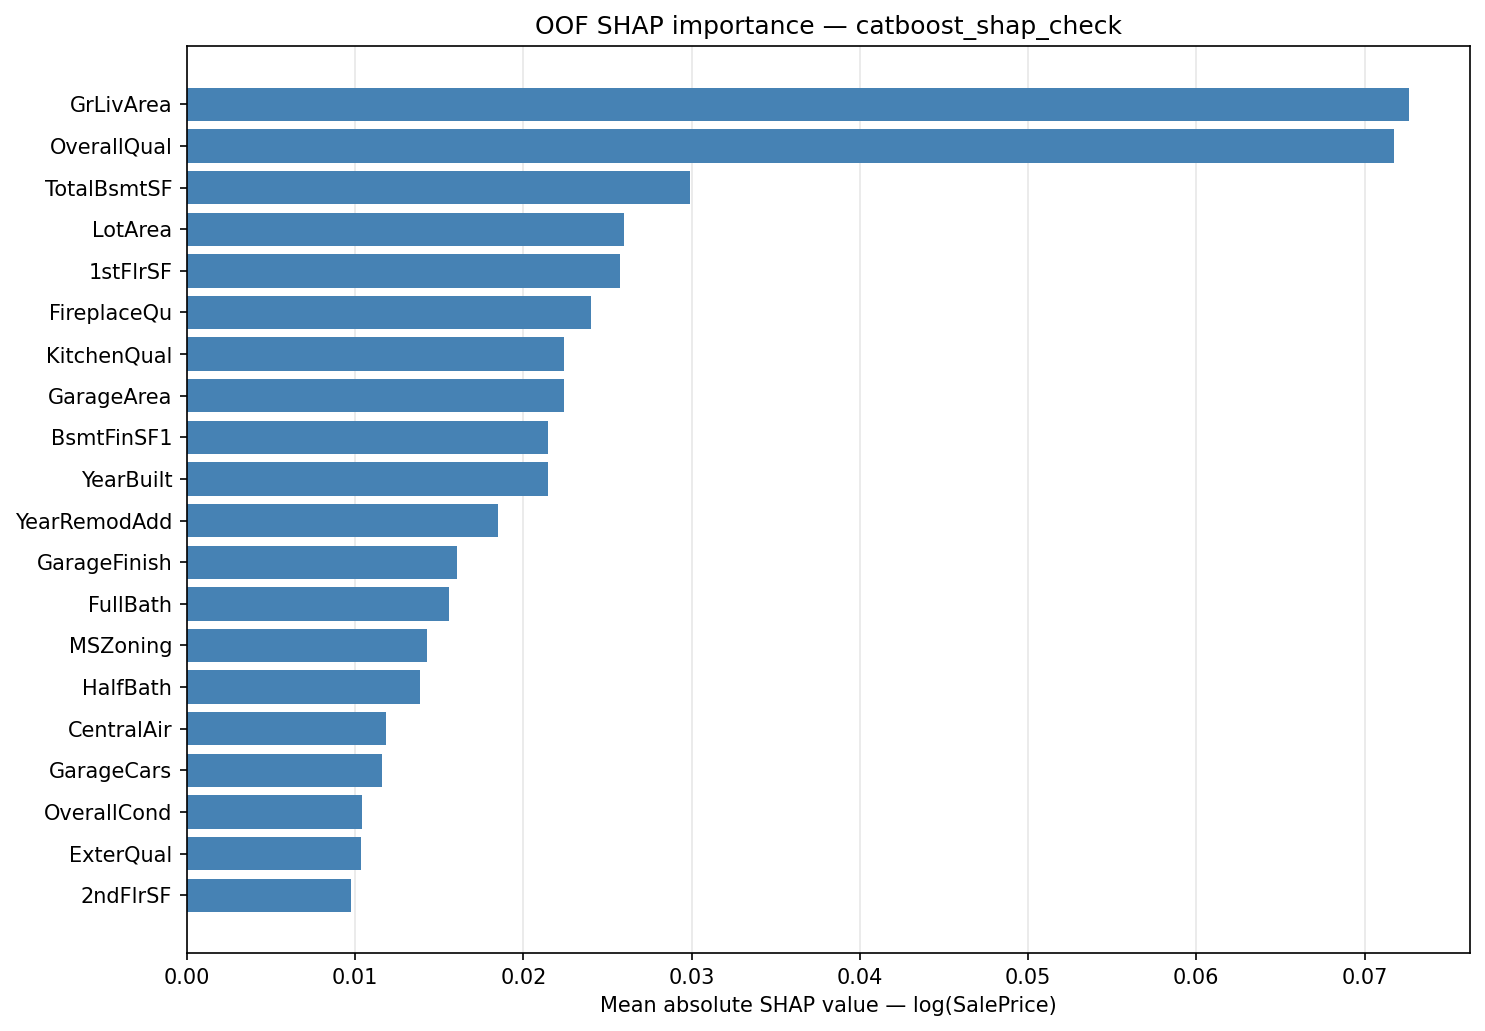

In [8]:
import importlib
from copy import deepcopy

import numpy as np
import pandas as pd
import src.shap_analysis as shap_module

from IPython.display import Image, display

importlib.reload(shap_module)

shap_check_config = deepcopy(smoke_config)
shap_check_config.general.experiment_name = 'catboost_shap_check'

importance_df, plot_path = shap_module.save_oof_shap(shap_result, shap_check_config)

# Проверяем, что CSV сохранил Id и позволяет восстановить прогноз из вкладов.
saved_contributions = pd.read_csv(plot_path.parent / 'oof_shap.csv', sep=';')
contribution_columns = [column for column in saved_contributions if column.startswith('shap__')]

np.testing.assert_array_equal(saved_contributions['Id'].to_numpy(), shap_result['ids'])

reconstructed_predictions = saved_contributions['base_value'] + saved_contributions[contribution_columns].sum(axis=1)
np.testing.assert_allclose(reconstructed_predictions, saved_contributions['prediction_log'], rtol=1e-6, atol=1e-8)

display(Image(filename=str(plot_path)))

OOF SHAP saved: outputs\shap\catboost_shap_check_shap.npz
SHAP feature values saved: outputs\shap\catboost_shap_check_features.csv
SHAP importance saved: outputs\shap\catboost_shap_check_importance.csv
SHAP importance plot saved: outputs\shap\catboost_shap_check_importance.png
    feature  mean_abs_shap
  GrLivArea       0.072653
OverallQual       0.071762
TotalBsmtSF       0.029899
    LotArea       0.026005
   1stFlrSF       0.025754
FireplaceQu       0.024023
KitchenQual       0.022393
 GarageArea       0.022392
 BsmtFinSF1       0.021454
  YearBuilt       0.021440


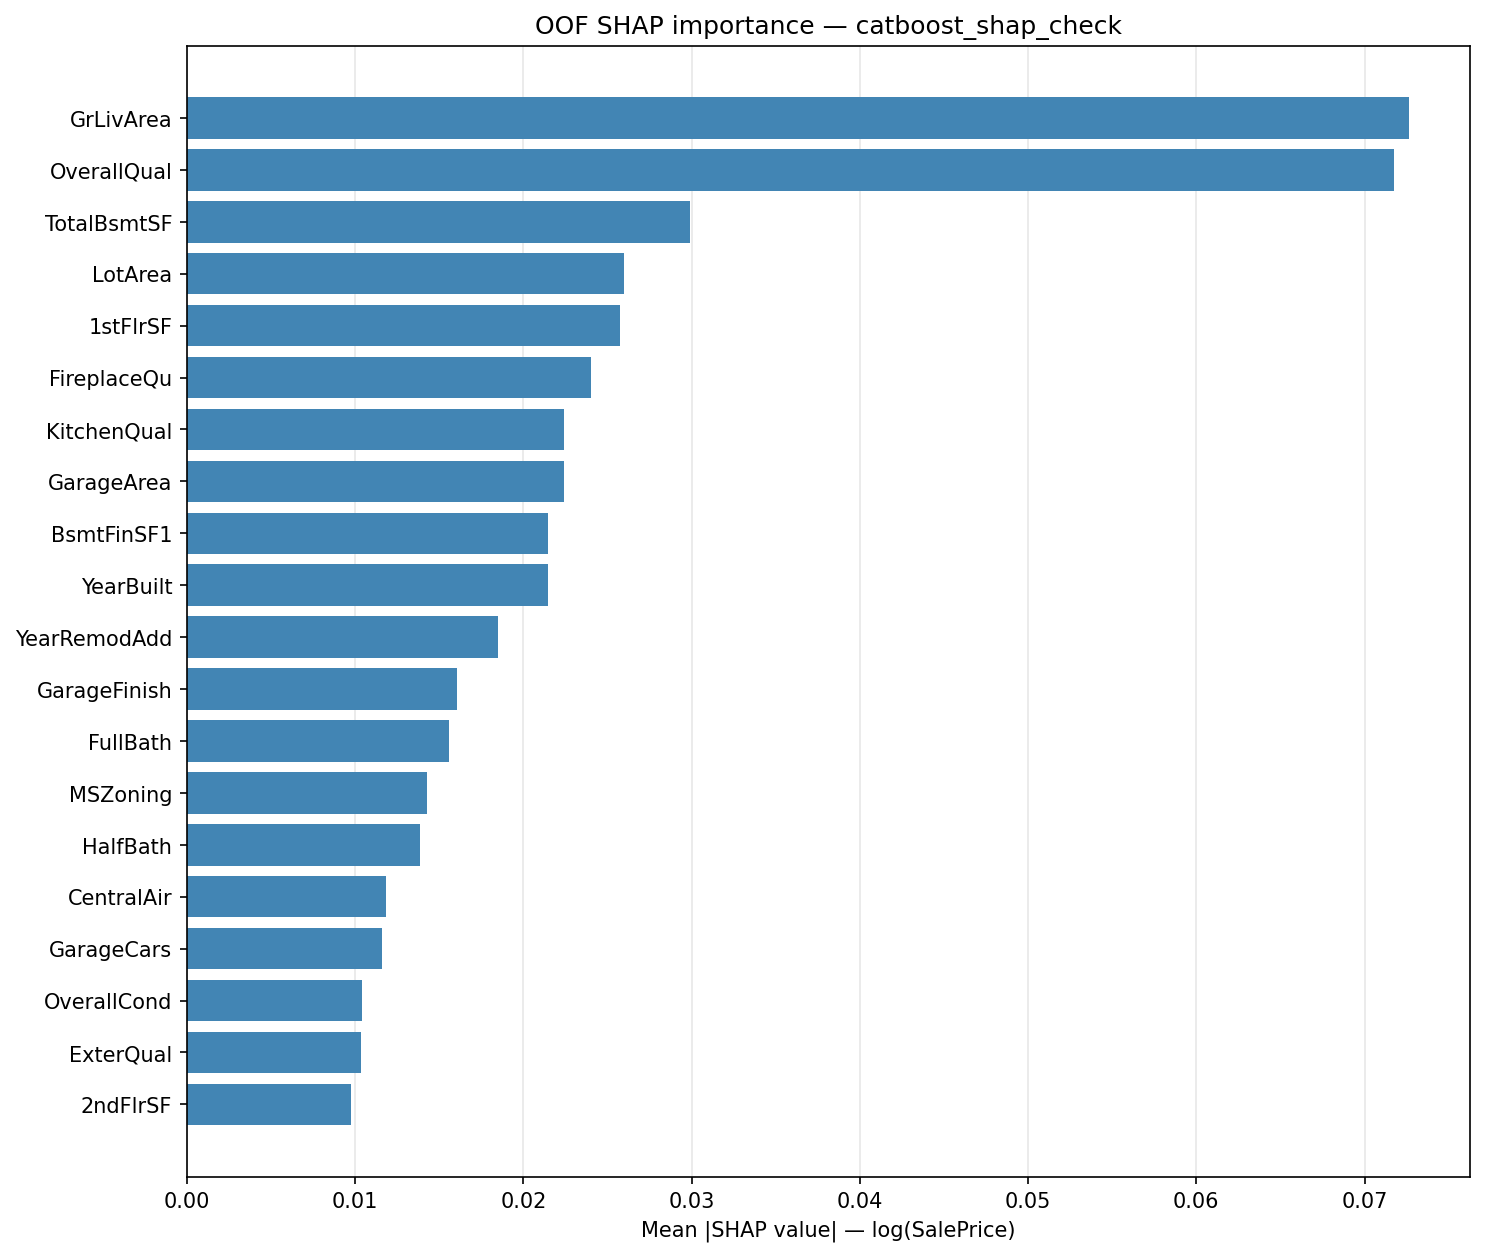

In [9]:
import importlib
from copy import deepcopy
from pathlib import Path

import numpy as np
import src.shap_analysis as shap_module

from IPython.display import Image, display

importlib.reload(shap_module)

check_config = deepcopy(smoke_config)
check_config.general.experiment_name = 'catboost_shap_check'

importance_df = shap_module.save_oof_shap(shap_result, check_config)
plot_path = shap_module.save_shap_importance_plot(importance_df, check_config)

# Проверяем сохранённые массивы: из них должен восстанавливаться тот же OOF-прогноз.
values_path = Path(check_config.paths.path_to_shap) / f'{check_config.general.experiment_name}_shap.npz'

with np.load(values_path, allow_pickle=False) as saved:
    reconstructed_predictions = saved['base_values'] + saved['shap_values'].sum(axis=1)
    np.testing.assert_allclose(reconstructed_predictions, oof_predictions, rtol=1e-6, atol=1e-8)
    np.testing.assert_array_equal(saved['ids'], shap_result['ids'])

print(importance_df.head(10).to_string(index=False))
display(Image(filename=str(plot_path)))

c:\Users\aukha\anaconda3\envs\house_prices\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\aukha\anaconda3\envs\house_prices\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


SHAP beeswarm plot saved: outputs\shap\catboost_shap_check_beeswarm.png


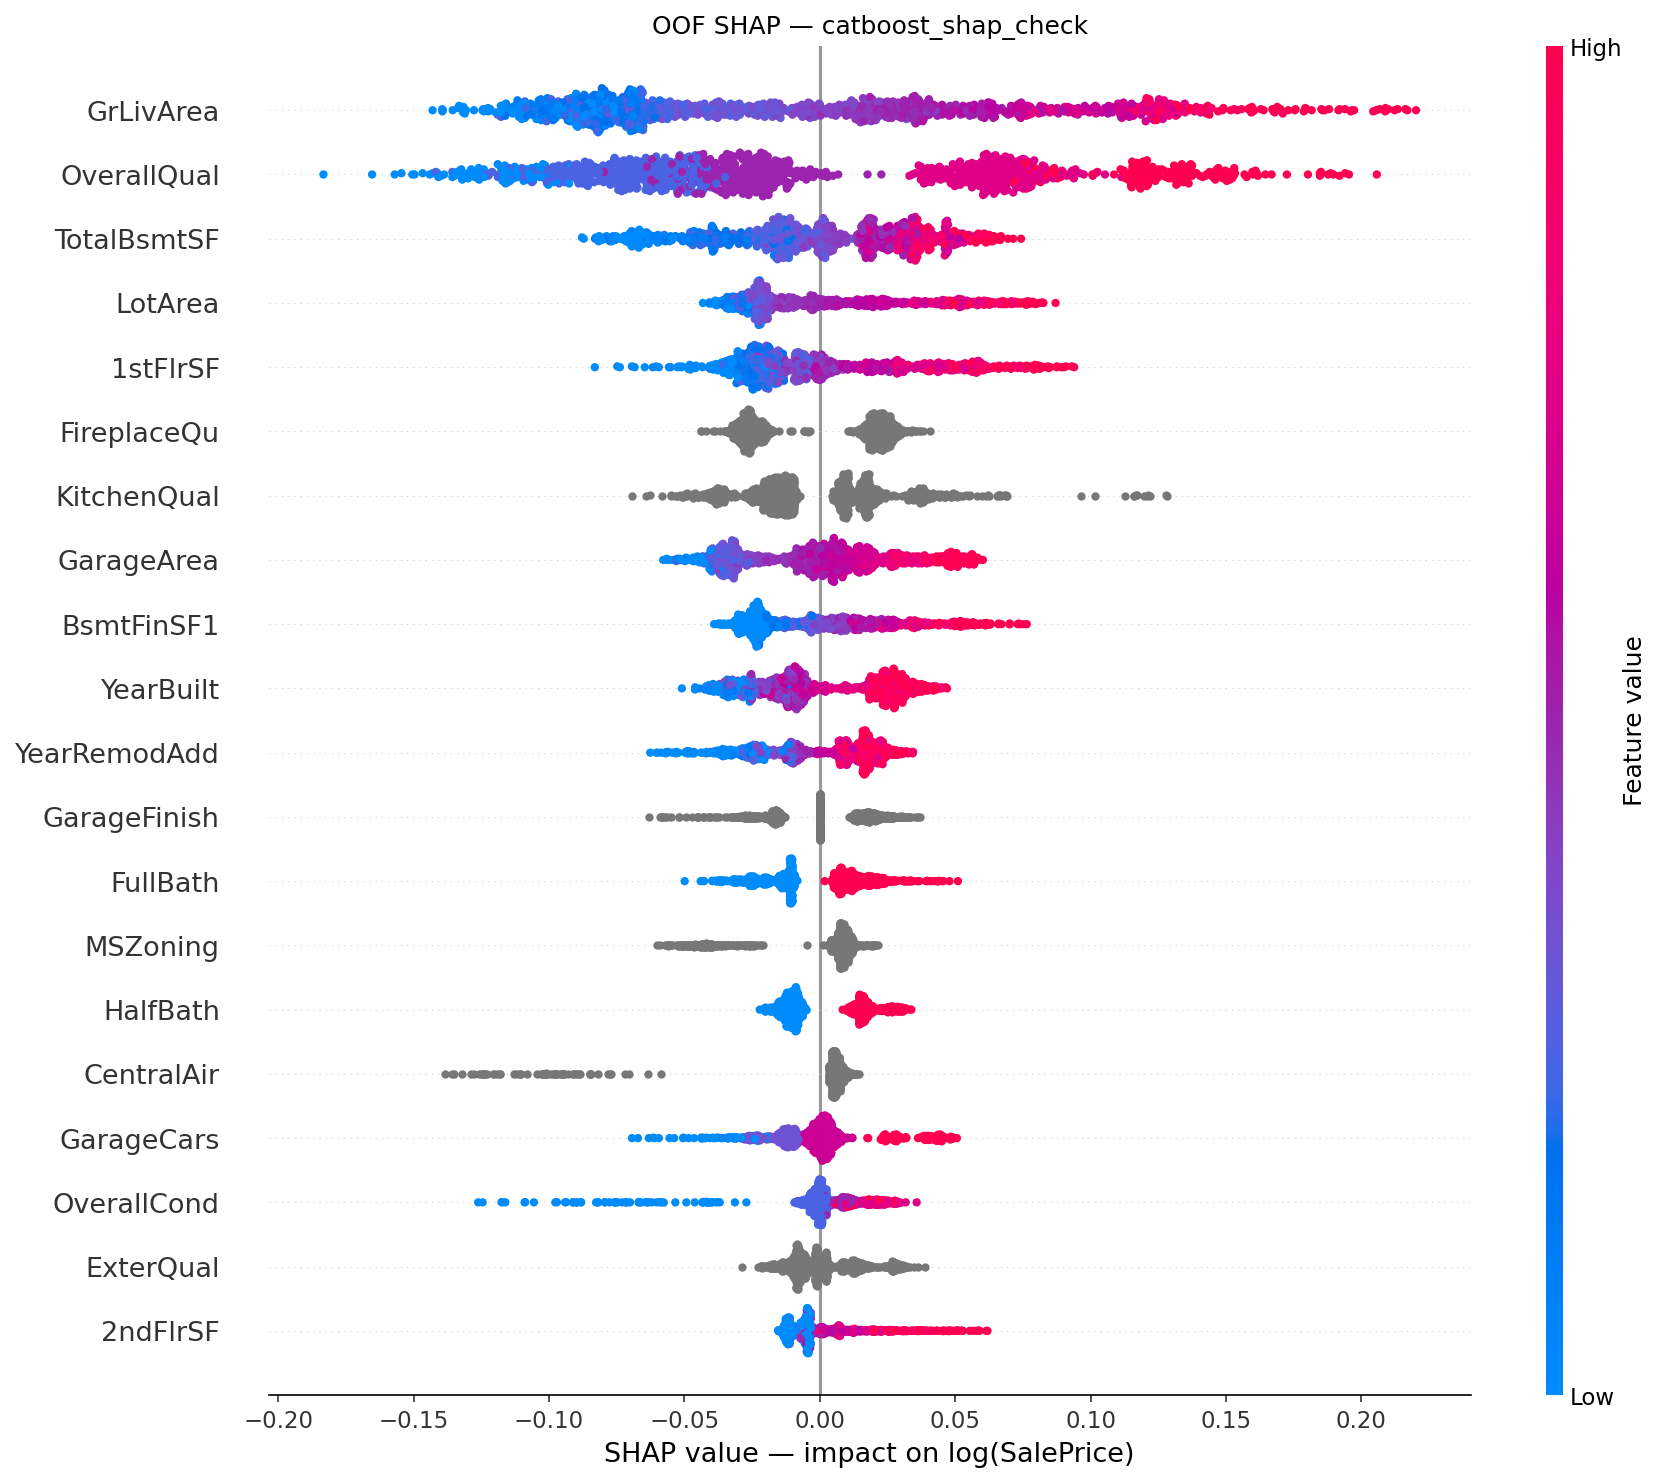

In [10]:
import importlib

import src.shap_analysis as shap_module

from IPython.display import Image, display

importlib.reload(shap_module)

plot_path = shap_module.save_shap_beeswarm_plot(shap_result, check_config)
display(Image(filename=str(plot_path)))

## Имплементация Catboost

In [7]:
import importlib
import json
from copy import deepcopy

import config as config_module
import src.data as data_module
import src.preprocessing as preprocessing_module
import src.train_functions as training_module
import src.experiment_logging as logging_module

# Обновляем модули в порядке зависимостей, чтобы использовать сохранённые изменения.
importlib.reload(config_module)
importlib.reload(data_module)
importlib.reload(preprocessing_module)
importlib.reload(training_module)
importlib.reload(logging_module)

# Изменяем только копию конфигурации; параметры основного эксперимента остаются прежними.
smoke_config = deepcopy(config_module.config)
smoke_config.general.experiment_name = 'catboost_training_history_check'
smoke_config.model.active = 'catboost'
smoke_config.model.models.catboost.iterations = 100
smoke_config.model.models.catboost.early_stopping_rounds = 10

train_df, _ = data_module.load_data(smoke_config)
train_cv_df, _ = data_module.split_train_holdout(train_df, smoke_config)

scores, fold_models, oof_predictions, fold_ids = training_module.cross_validate_model_with_early_stopping(
    train_cv_df=train_cv_df,
    target_col='SalePrice',
    config=smoke_config,
)

history_path = logging_module.save_catboost_training_history(fold_models, smoke_config)

# Читаем JSON с диска и сравниваем его с историей обученных моделей.
with history_path.open('r', encoding='utf-8') as file:
    saved_history = json.load(file)

assert len(saved_history['folds']) == smoke_config.split.n_splits

for fold_history, pipe in zip(saved_history['folds'], fold_models):
    model = pipe.named_steps['model']
    expected_history = model.get_evals_result()

    assert fold_history['train_rmse'] == expected_history['learn']['RMSE']
    assert fold_history['validation_rmse'] == expected_history['validation']['RMSE']
    assert fold_history['best_iteration'] == model.get_best_iteration() + 1
    assert fold_history['trees_retained'] == model.tree_count_

print(f'\nExperiment: {saved_history["experiment_name"]}')
print(f'Configured iterations: {saved_history["parameters"]["iterations"]}')
print(f'Saved folds: {len(saved_history["folds"])}')
print(f'Iterations per fold: {[len(fold["validation_rmse"]) for fold in saved_history["folds"]]}')
print(f'History file: {history_path}')

Removed EDA outliers: [524, 1299] (1168 -> 1166)
Fold 1: RMSE(log) = 0.15110, best iteration = 100, iterations run = 100, trees retained = 100
Fold 2: RMSE(log) = 0.14794, best iteration = 100, iterations run = 100, trees retained = 100
Fold 3: RMSE(log) = 0.16393, best iteration = 100, iterations run = 100, trees retained = 100
Fold 4: RMSE(log) = 0.15203, best iteration = 100, iterations run = 100, trees retained = 100
Fold 5: RMSE(log) = 0.14418, best iteration = 100, iterations run = 100, trees retained = 100
Training history saved: outputs\logs\training_history\catboost_training_history_check.json

Experiment: catboost_training_history_check
Configured iterations: 100
Saved folds: 5
Iterations per fold: [100, 100, 100, 100, 100]
History file: outputs\logs\training_history\catboost_training_history_check.json


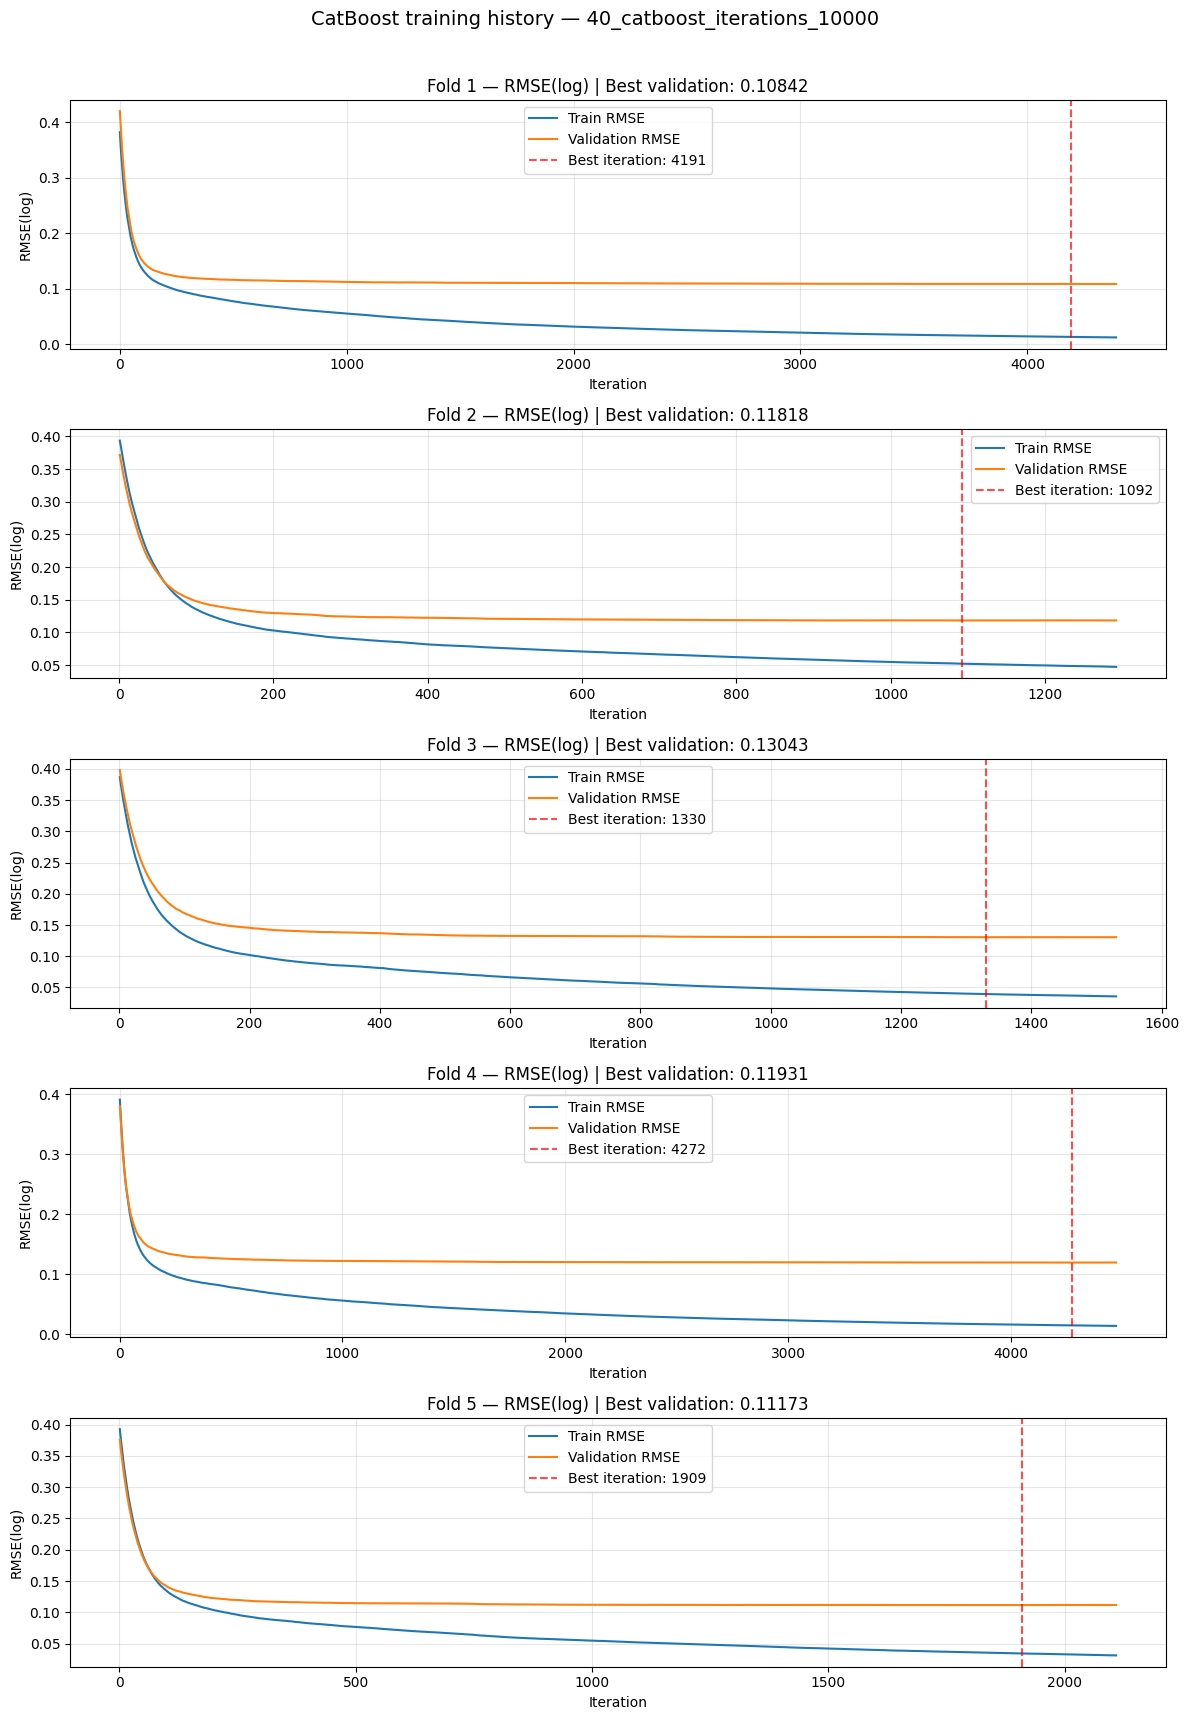

In [9]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def plot_catboost_training_history(history_path, start_iteration=1):
    '''Plot per-fold training and validation RMSE from a saved JSON history.'''

    if start_iteration < 1:
        raise ValueError('start_iteration must be positive.')

    with Path(history_path).open('r', encoding='utf-8') as file:
        history = json.load(file)

    folds = history['folds']

    if not folds:
        raise ValueError('Training history contains no folds.')

    figure, axes = plt.subplots(len(folds), 1, figsize=(12, 3.5 * len(folds)), squeeze=False)

    for axis, fold_history in zip(axes[:, 0], folds):
        train_rmse = np.asarray(fold_history['train_rmse'])
        validation_rmse = np.asarray(fold_history['validation_rmse'])
        iterations = np.arange(1, len(validation_rmse) + 1)

        best_iteration = fold_history['best_iteration']
        best_rmse = validation_rmse[best_iteration - 1]

        # Zoom меняет только отображение: история и лучшая итерация остаются исходными.
        visible = iterations >= start_iteration

        if not visible.any():
            axis.set_title(f'Fold {fold_history["fold"]} — training ended at iteration {len(iterations)}')
            axis.text(0.5, 0.5, 'No iterations in the selected range', ha='center', va='center', transform=axis.transAxes)
            continue

        axis.plot(iterations[visible], train_rmse[visible], label='Train RMSE')
        axis.plot(iterations[visible], validation_rmse[visible], label='Validation RMSE')

        if best_iteration >= start_iteration:
            axis.axvline(best_iteration, color='red', linestyle='--', alpha=0.7, label=f'Best iteration: {best_iteration}')

        axis.set_title(f'Fold {fold_history["fold"]} — RMSE(log) | Best validation: {best_rmse:.5f}')
        axis.set_xlabel('Iteration')
        axis.set_ylabel('RMSE(log)')
        axis.grid(alpha=0.3)
        axis.legend()

    figure.suptitle(f'CatBoost training history — {history["experiment_name"]}', fontsize=14)
    figure.tight_layout(rect=(0, 0, 1, 0.97))

    return figure


history_path = Path('outputs/logs/training_history/40_catboost_iterations_10000.json')

figure = plot_catboost_training_history(history_path)
plt.show()
plt.close(figure)

## Optuna

In [7]:
import gc
import optuna

from contextlib import redirect_stdout
from copy import deepcopy
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import root_mean_squared_error

from src.train_functions import cross_validate_standard

c:\Users\aukha\anaconda3\envs\house_prices\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
if config.model.active != 'random_forest':
    raise ValueError('Random Forest must be the active model during tuning.')

labels_log = np.log(train_cv_df['SalePrice'])

optuna_dir = Path('outputs/optuna')
optuna_dir.mkdir(parents=True, exist_ok=True)

In [9]:
def objective_rf(trial):
    trial_config = deepcopy(config)

    rf_config = trial_config.model.models.random_forest
    rf_config.n_estimators = trial.suggest_int('n_estimators', 200, 1200, step=100)
    rf_config.max_depth = trial.suggest_categorical('max_depth', [None, 5, 8, 12, 16, 24, 32])
    rf_config.min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    rf_config.min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    rf_config.max_features = trial.suggest_categorical(
        'max_features',
        ['sqrt', 'log2', 0.2, 0.4, 0.6, 0.8, 1.0],
    )
    rf_config.bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    rf_config.oob_score = False
    rf_config.random_state = config.general.seed
    rf_config.n_jobs = -1

    with redirect_stdout(StringIO()):
        scores, fold_models, oof_predictions, _ = cross_validate_standard(
            train_cv_df,
            'SalePrice',
            trial_config,
        )

    mean_cv_rmse = float(np.mean(scores))
    cv_std = float(np.std(scores))
    oof_rmse = float(root_mean_squared_error(labels_log, oof_predictions))

    trial.set_user_attr('cv_std', cv_std)
    trial.set_user_attr('oof_rmse', oof_rmse)

    del fold_models, oof_predictions
    gc.collect()

    return mean_cv_rmse

In [10]:
import optuna
import nbformat

print(f'nbformat: {nbformat.__version__}')

study_rf = optuna.load_study(
    study_name='random_forest_selected_features',
    storage='sqlite:///outputs/optuna/random_forest.db',
)

print(f'Loaded trials: {len(study_rf.trials)}')
print(f'Best CV RMSE(log): {study_rf.best_value:.5f}')
print(study_rf.best_params)

nbformat: 5.11.1
Loaded trials: 80
Best CV RMSE(log): 0.13219
{'n_estimators': 1200, 'max_depth': None, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 0.4, 'bootstrap': False}


In [ ]:
# sampler = optuna.samplers.TPESampler(seed=config.general.seed)

# study_rf = optuna.create_study(
#     study_name='random_forest_selected_features',
#     storage='sqlite:///outputs/optuna/random_forest.db',
#     direction='minimize',
#     sampler=sampler,
#     load_if_exists=True,
# )

# study_rf.optimize(objective_rf, n_trials=80, n_jobs=1, show_progress_bar=True)

[I 2026-09-10 15:20:10,237] A new study created in RDB with name: random_forest_selected_features
Best trial: 0. Best value: 0.185438:   1%|▏         | 1/80 [00:06<08:05,  6.14s/it]

[I 2026-09-10 15:20:16,378] Trial 0 finished with value: 0.1854379791113605 and parameters: {'n_estimators': 800, 'max_depth': 16, 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_features': 1.0, 'bootstrap': False}. Best is trial 0 with value: 0.1854379791113605.


Best trial: 1. Best value: 0.150853:   2%|▎         | 2/80 [00:10<06:42,  5.16s/it]

[I 2026-09-10 15:20:20,843] Trial 1 finished with value: 0.15085278090161586 and parameters: {'n_estimators': 1200, 'max_depth': None, 'min_samples_split': 17, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 1 with value: 0.15085278090161586.


Best trial: 2. Best value: 0.145266:   4%|▍         | 3/80 [00:13<05:33,  4.34s/it]

...

[I 2026-09-10 15:29:47,709] Trial 77 finished with value: 0.13237694737610814 and parameters: {'n_estimators': 1200, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.4, 'bootstrap': False}. Best is trial 46 with value: 0.1321917154267303.


Best trial: 46. Best value: 0.132192:  99%|█████████▉| 79/80 [09:45<00:09,  9.83s/it]

[I 2026-09-10 15:29:56,056] Trial 78 finished with value: 0.13328638468666804 and parameters: {'n_estimators': 1200, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 0.2, 'bootstrap': False}. Best is trial 46 with value: 0.1321917154267303.


Best trial: 46. Best value: 0.132192: 100%|██████████| 80/80 [10:01<00:00,  7.52s/it]

[I 2026-09-10 15:30:11,743] Trial 79 finished with value: 0.13509090285173195 and parameters: {'n_estimators': 1200, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.6, 'bootstrap': False}. Best is trial 46 with value: 0.1321917154267303.


In [11]:
print(f'Best CV RMSE(log): {study_rf.best_value:.5f}')
print('Best parameters:')
display(study_rf.best_params)

rf_trials_df = study_rf.trials_dataframe()
rf_trials_df = rf_trials_df[rf_trials_df['state'] == 'COMPLETE']
rf_trials_df = rf_trials_df.sort_values('value').reset_index(drop=True)

display(rf_trials_df.head(15))

Best CV RMSE(log): 0.13219
Best parameters:


{'n_estimators': 1200,
 'max_depth': None,
 'min_samples_split': 6,
 'min_samples_leaf': 1,
 'max_features': 0.4,
 'bootstrap': False}

,number,value,datetime_start,datetime_complete,duration,params_bootstrap,params_max_depth,params_max_features,params_min_samples_leaf,params_min_samples_split,params_n_estimators,user_attrs_cv_std,user_attrs_oof_rmse,state
0,46,0.132192,2026-09-10 15:25:23.301751,2026-09-10 15:25:34.331518,0 days 00:00:11.029767,False,NaN,0.4,1,6,1200,0.010638,0.132604,COMPLETE
1,64,0.132260,2026-09-10 15:27:49.380891,2026-09-10 15:27:56.501785,0 days 00:00:07.120894,False,12.0,0.4,2,4,900,0.010376,0.132652,COMPLETE
2,26,0.132281,2026-09-10 15:22:35.395278,2026-09-10 15:22:42.738504,0 days 00:00:07.343226,False,12.0,0.4,2,3,1000,0.010286,0.132666,COMPLETE
3,77,0.132377,2026-09-10 15:29:35.151320,2026-09-10 15:29:47.701548,0 days 00:00:12.550228,False,12.0,0.4,2,4,1200,0.010216,0.132756,COMPLETE
4,32,0.132377,2026-09-10 15:23:15.606161,2026-09-10 15:23:24.363492,0 days 00:00:08.757331,False,12.0,0.4,2,3,1200,0.010216,0.132756,COMPLETE
5,41,0.132387,2026-09-10 15:24:32.923135,2026-09-10 15:24:43.208777,0 days 00:00:10.285642,False,12.0,0.4,2,3,1100,0.010303,0.132773,COMPLETE
6,61,0.132387,2026-09-10 15:27:23.422960,2026-09-10 15:27:33.239886,0 days 00:00:09.816926,False,12.0,0.4,2,3,1100,0.010303,0.132773,COMPLETE
7,31,0.132387,2026-09-10 15:23:07.662730,2026-09-10 15:23:15.590471,0 days 00:00:07.927741,False,12.0,0.4,2,2,1100,0.010303,0.132773,COMPLETE
8,25,0.132387,2026-09-10 15:22:27.384207,2026-09-10 15:22:35.371037,0 days 00:00:07.986830,False,12.0,0.4,2,4,1100,0.010303,0.132773,COMPLETE
9,62,0.132387,2026-09-10 15:27:33.257172,2026-09-10 15:27:42.105742,0 days 00:00:08.848570,False,12.0,0.4,2,2,1100,0.010303,0.132773,COMPLETE


In [12]:
optuna.visualization.plot_optimization_history(study_rf).show()
optuna.visualization.plot_param_importances(study_rf).show()

## Прототип Shap

c:\Users\aukha\anaconda3\envs\house_prices\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,mean_abs_shap
0,numerical__2ndFlrSF,0.058973
1,numerical__OverallQual,0.052209
2,numerical__GrLivArea,0.047951
3,numerical__1stFlrSF,0.041683
4,numerical__YearBuilt,0.040508
5,numerical__OverallCond,0.039561
6,categorical__MSZoning_RL,0.035312
7,numerical__TotalBsmtSF,0.035063
8,categorical__KitchenQual_Gd,0.026929
9,numerical__LotArea,0.025971


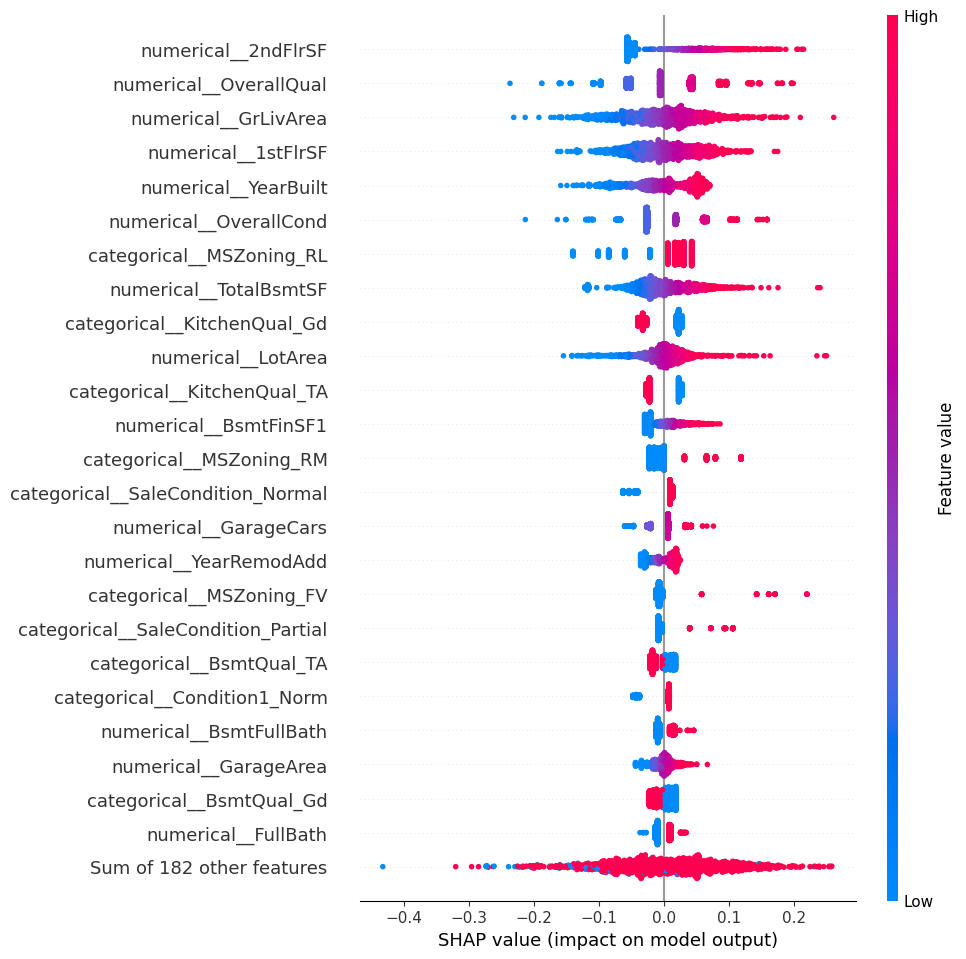

In [9]:
import warnings
from contextlib import redirect_stdout
from io import StringIO

import numpy as np
import pandas as pd
import shap

from src.train_functions import build_pipeline, cross_validate_standard

features = train_cv_df.drop(columns=['SalePrice'])

# assert config.general.experiment_name == '11_elastic_net_selected_log1p'
assert list(build_pipeline(config).named_steps) == ['selected_log1p', 'preprocessor', 'model']

oof_shap_parts = []
oof_transformed_parts = []

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='Found unknown categories')

    # Повторяем CV, чтобы получить модели, обученные без соответствующих validation folds.
    with redirect_stdout(StringIO()):
        scores, fold_models, oof_predictions, fold_ids = cross_validate_standard(train_cv_df, 'SalePrice', config)

    for fold_index, pipe in enumerate(fold_models):
        train_mask = fold_ids != fold_index
        validation_mask = fold_ids == fold_index

        train_features = features.loc[train_mask]
        validation_features = features.loc[validation_mask]

        feature_pipeline = pipe[:-1]
        model = pipe.named_steps['model']

        train_transformed = feature_pipeline.transform(train_features)
        validation_transformed = feature_pipeline.transform(validation_features)
        feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()

        # Каждый validation fold объясняется моделью, которая не обучалась на этих домах.
        masker = shap.maskers.Independent(train_transformed, max_samples=len(train_transformed))
        explainer = shap.LinearExplainer(model, masker)
        fold_explanation = explainer(validation_transformed)

        oof_shap_parts.append(
            pd.DataFrame(fold_explanation.values, index=validation_features.index, columns=feature_names)
        )
        oof_transformed_parts.append(
            pd.DataFrame(validation_transformed, index=validation_features.index, columns=feature_names)
        )

oof_shap_df = pd.concat(oof_shap_parts).reindex(features.index).fillna(0)
oof_transformed_df = pd.concat(oof_transformed_parts).reindex(features.index).fillna(0)

assert oof_shap_df.shape == oof_transformed_df.shape
assert len(oof_shap_df) == len(train_cv_df)
assert np.isfinite(oof_shap_df.to_numpy()).all()

shap_encoded_importance_df = (
    oof_shap_df.abs()
    .mean()
    .sort_values(ascending=False)
    .rename('mean_abs_shap')
    .rename_axis('feature')
    .reset_index()
)

display(shap_encoded_importance_df.head(20))

oof_explanation = shap.Explanation(
    values=oof_shap_df.to_numpy(),
    data=oof_transformed_df.to_numpy(),
    feature_names=oof_shap_df.columns.tolist(),
)

shap.plots.beeswarm(oof_explanation, max_display=25)

,feature,mean_abs_shap
0,2ndFlrSF,0.058973
1,OverallQual,0.052209
2,GrLivArea,0.047951
3,1stFlrSF,0.041683
4,YearBuilt,0.040508
5,OverallCond,0.039561
6,TotalBsmtSF,0.035063
7,LotArea,0.025971
8,BsmtFinSF1,0.020324
9,Neighborhood,0.017442


,feature,mean_abs_shap
41,BsmtCond,0.002715
42,LotFrontage,0.002578
43,BsmtFinSF2,0.002489
44,GarageFinish,0.002193
45,OpenPorchSF,0.001912
46,MoSold,0.001761
47,GarageCond,0.001740
48,LotShape,0.001713
49,BsmtFinType2,0.001400
50,PoolArea,0.001157


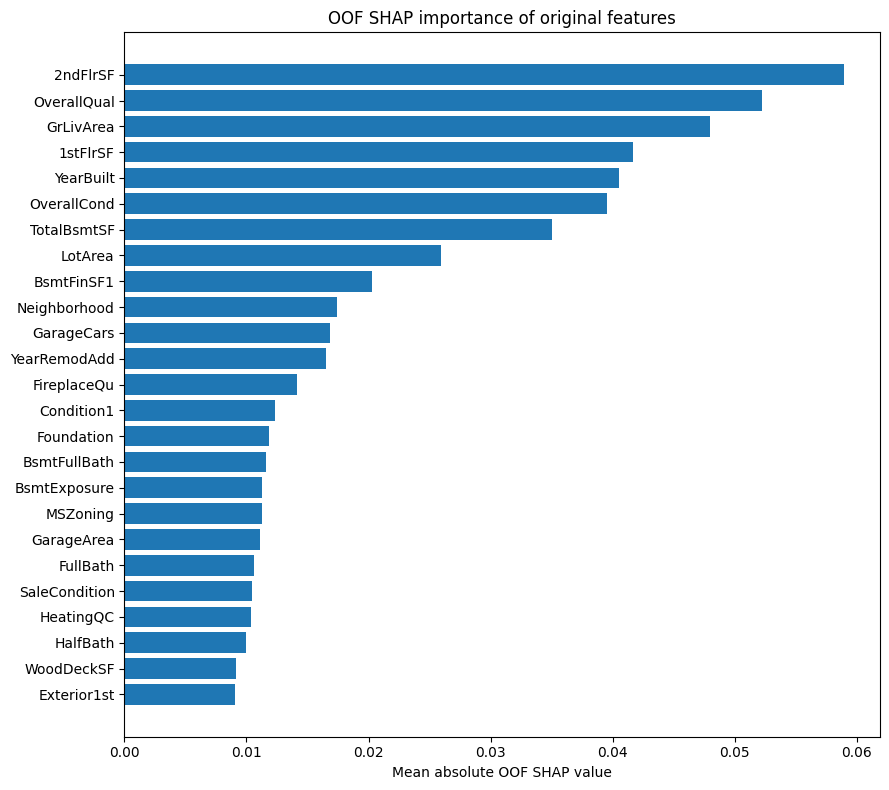

In [10]:
# Объединяем SHAP-вклады закодированных колонок до уровня исходных features.
raw_features = train_cv_df.drop(columns=['SalePrice', 'Id'], errors='ignore')
categorical_features = sorted(raw_features.select_dtypes(exclude=np.number).columns, key=len, reverse=True)

def get_original_feature(encoded_feature):
    '''Return the original feature name for an encoded feature.'''
    if encoded_feature.startswith('numerical__'):
        return encoded_feature.removeprefix('numerical__')

    encoded_name = encoded_feature.removeprefix('categorical__')
    for feature in categorical_features:
        if encoded_name == feature or encoded_name.startswith(f'{feature}_'):
            return feature

    raise ValueError(f'Original feature was not found: {encoded_feature}')

feature_map = pd.Series(
    {feature: get_original_feature(feature) for feature in oof_shap_df.columns},
    name='original_feature',
)

original_oof_shap_df = oof_shap_df.T.groupby(feature_map).sum().T
original_shap_importance_df = (
    original_oof_shap_df.abs().mean()
    .sort_values(ascending=False)
    .rename_axis('feature')
    .reset_index(name='mean_abs_shap')
)

display(original_shap_importance_df.head(25))
display(original_shap_importance_df.tail(20))

top_original_features = original_shap_importance_df.head(25).sort_values('mean_abs_shap')

plt.figure(figsize=(9, 8))
plt.barh(top_original_features['feature'], top_original_features['mean_abs_shap'])
plt.xlabel('Mean absolute OOF SHAP value')
plt.ylabel('')
plt.title('OOF SHAP importance of original features')
plt.tight_layout()
plt.show()

In [11]:
# Проверяем полноту сопоставления и сохранение суммарного SHAP-вклада.
mapped_features = set(feature_map)
expected_features = set(raw_features.columns)

# assert len(original_shap_importance_df) == raw_features.shape[1]
# assert mapped_features == expected_features
np.testing.assert_allclose(
    oof_shap_df.sum(axis=1),
    original_oof_shap_df.sum(axis=1),
    rtol=1e-10,
    atol=1e-10,
)

print(f'Encoded features: {oof_shap_df.shape[1]}')
print(f'Original features: {original_oof_shap_df.shape[1]}')
print('SHAP aggregation check passed.')

Encoded features: 206
Original features: 61
SHAP aggregation check passed.


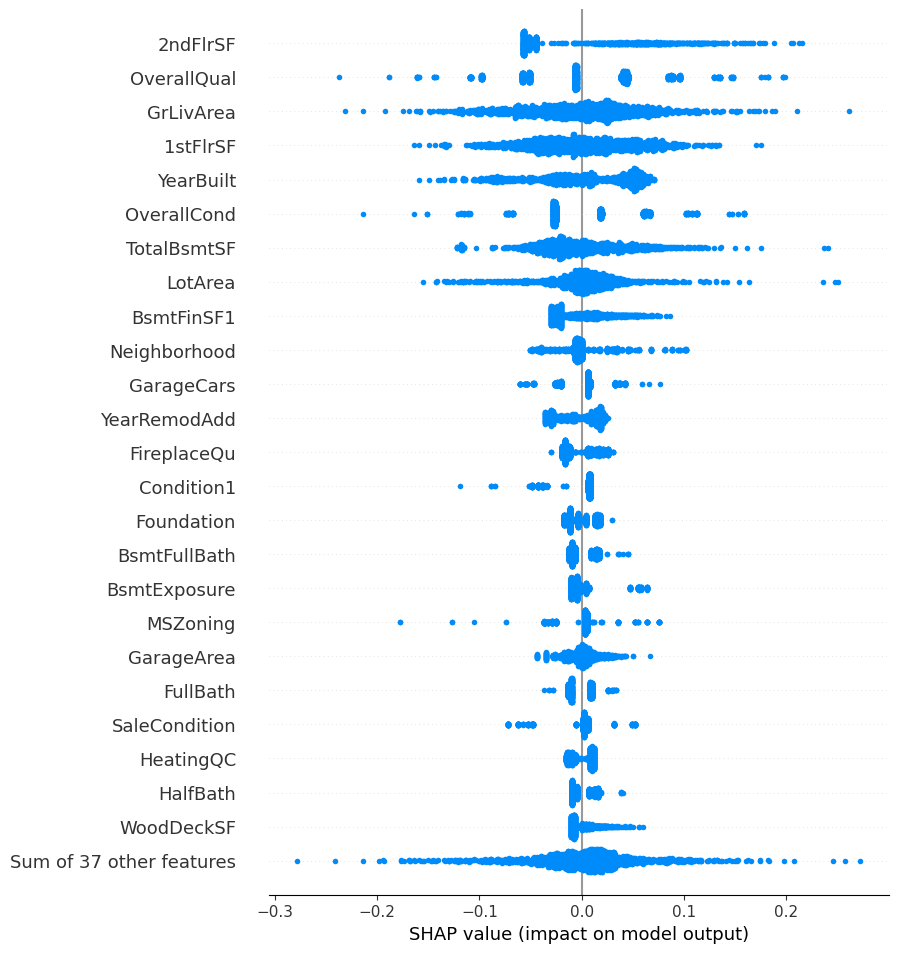

In [12]:
original_oof_explanation = shap.Explanation(
    values=original_oof_shap_df.to_numpy(),
    feature_names=original_oof_shap_df.columns.tolist(),
    # data=oof_transformed_df.to_numpy(),
)


shap.plots.beeswarm(original_oof_explanation, max_display=25)

c:\Users\aukha\anaconda3\envs\house_prices\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


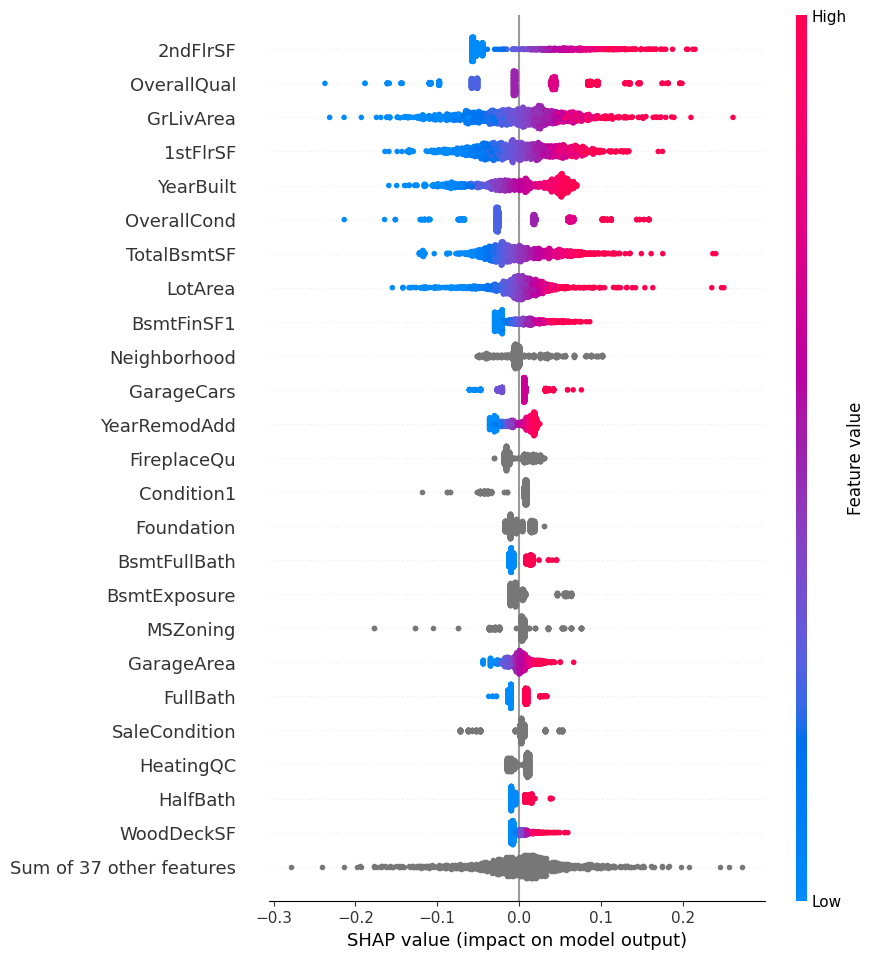

In [13]:
# Подготавливаем исходные числовые значения для окрашивания точек.
original_feature_names = original_oof_shap_df.columns.tolist()

assert original_oof_shap_df.index.isin(raw_features.index).all()

original_plot_data = raw_features.loc[
    original_oof_shap_df.index,
    original_feature_names,
].copy()

for feature in original_feature_names:
    if pd.api.types.is_numeric_dtype(original_plot_data[feature]):
        original_plot_data[feature] = original_plot_data[feature].fillna(
            original_plot_data[feature].median()
        )
    else:
        original_plot_data[feature] = np.nan

original_oof_explanation = shap.Explanation(
    values=original_oof_shap_df.to_numpy(),
    data=original_plot_data.to_numpy(dtype=float),
    feature_names=original_feature_names,
)

shap.plots.beeswarm(original_oof_explanation, max_display=25)

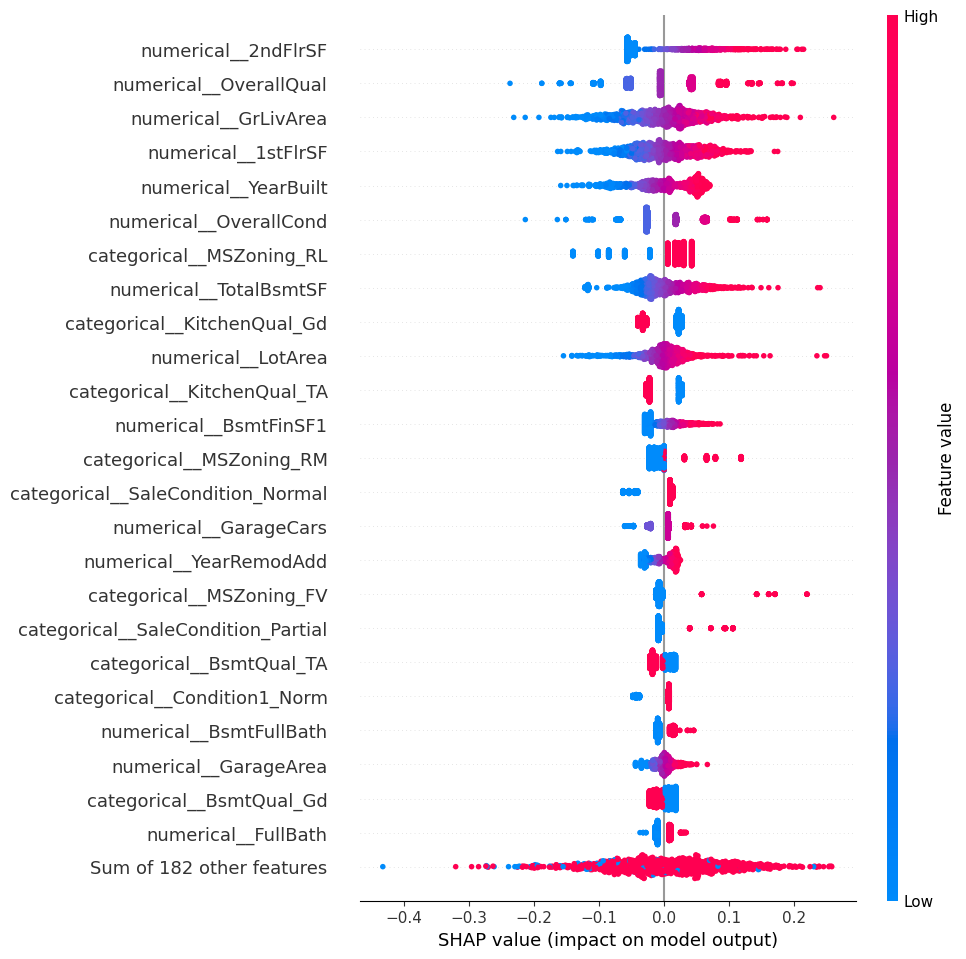

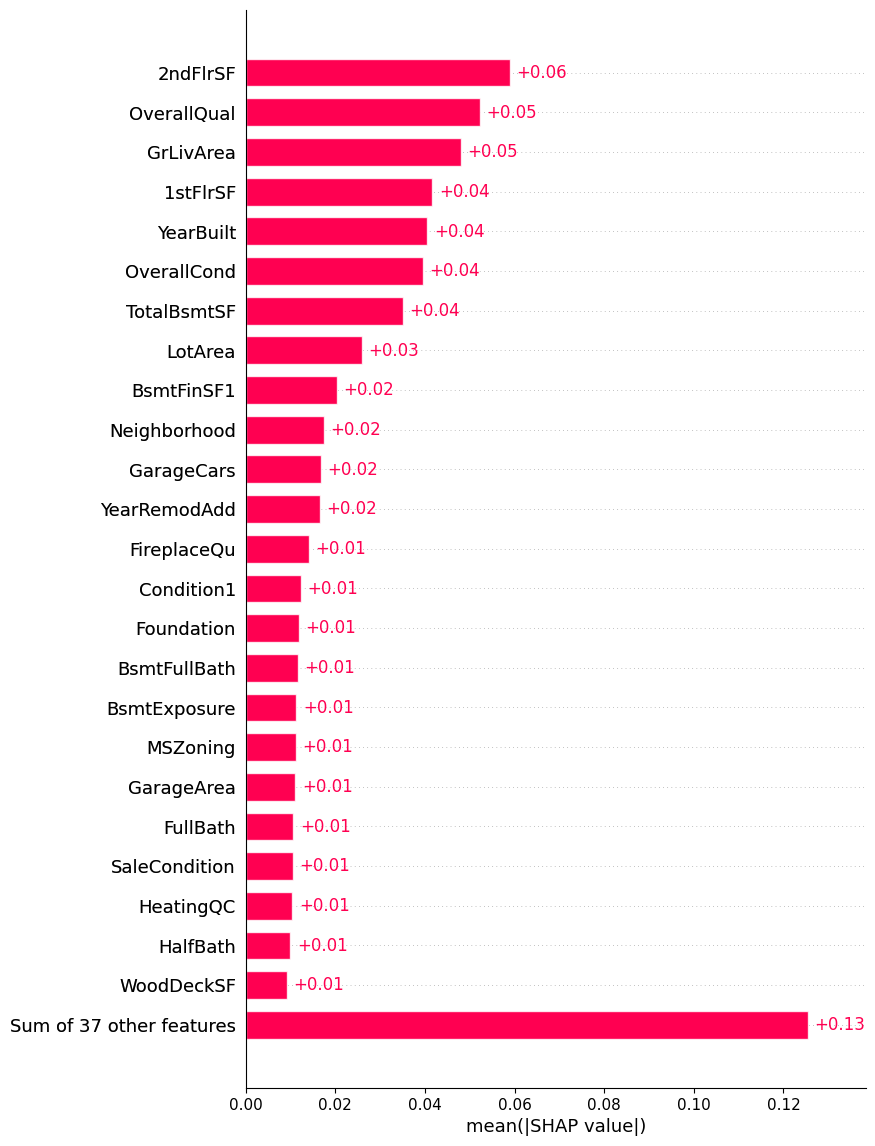

In [14]:
# Детальное направление влияния закодированных признаков.
shap.plots.beeswarm(oof_explanation, max_display=25)

# Общая важность исходных features.
shap.plots.bar(original_oof_explanation, max_display=25)

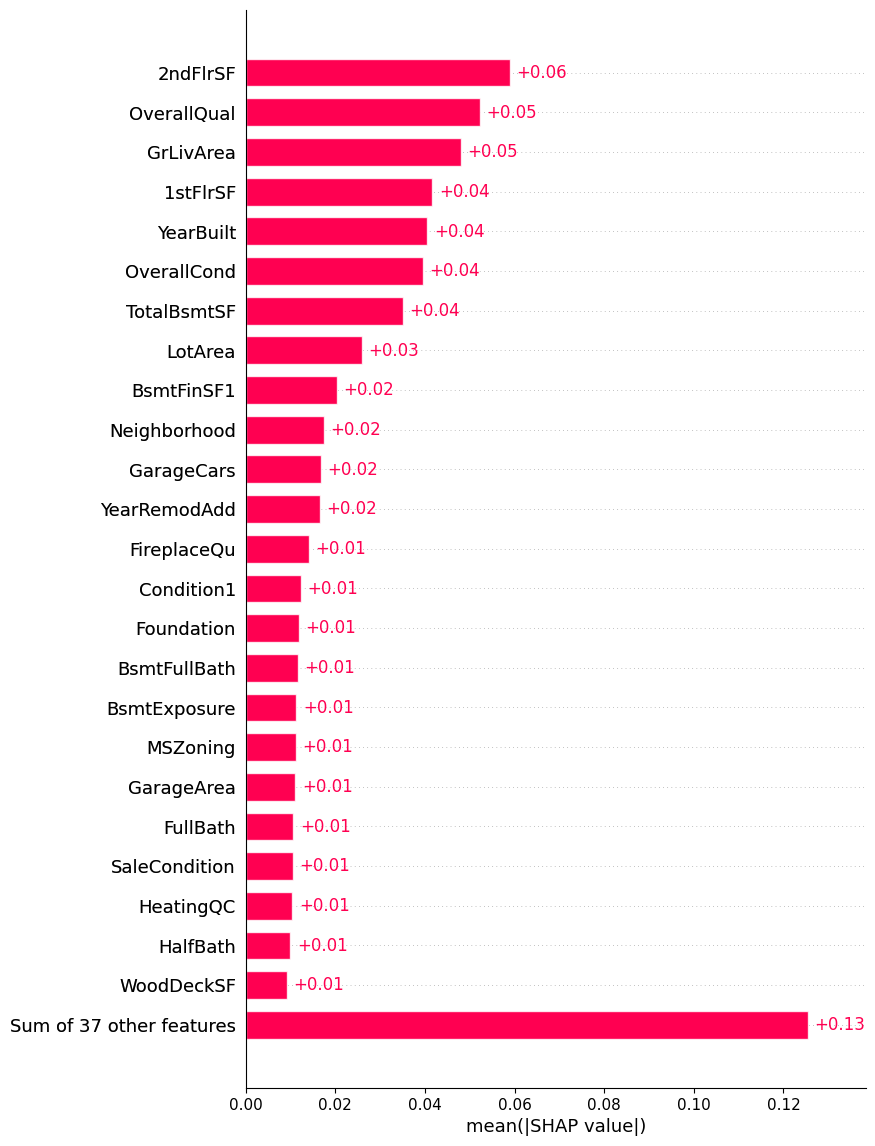

c:\Users\aukha\anaconda3\envs\house_prices\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


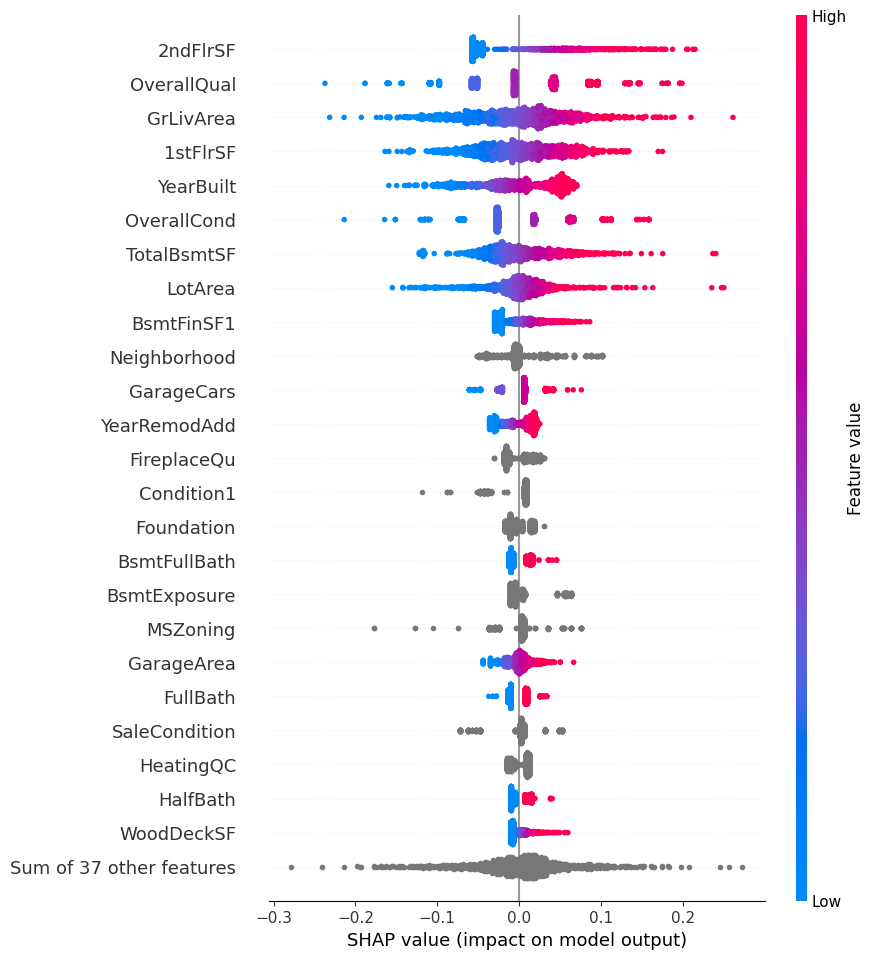

,feature,mean_abs_shap
0,2ndFlrSF,0.058973
1,OverallQual,0.052209
2,GrLivArea,0.047951
3,1stFlrSF,0.041683
4,YearBuilt,0.040508
...,...,...
56,LandContour,0.000554
57,LandSlope,0.000424
58,3SsnPorch,0.000293
59,MiscVal,0.000285


In [15]:
# Глобальный рейтинг исходных features.
shap.plots.bar(original_oof_explanation, max_display=25)

# Направление и распределение влияния исходных features.
shap.plots.beeswarm(original_oof_explanation, max_display=25)

# Полный рейтинг для подготовки feature selection.
display(original_shap_importance_df)

In [16]:
from pathlib import Path

shap_output_dir = Path('outputs/shap')
shap_output_dir.mkdir(parents=True, exist_ok=True)

baseline_shap_df = original_shap_importance_df.copy()
baseline_shap_df.insert(0, 'rank', np.arange(1, len(baseline_shap_df) + 1))
baseline_shap_df.to_csv(
    shap_output_dir / '29_elastic_net_return_garage_condition_shap.csv',
    index=False,
)

display(baseline_shap_df)

,rank,feature,mean_abs_shap
0,1,2ndFlrSF,0.058973
1,2,OverallQual,0.052209
2,3,GrLivArea,0.047951
3,4,1stFlrSF,0.041683
4,5,YearBuilt,0.040508
...,...,...,...
56,57,LandContour,0.000554
57,58,LandSlope,0.000424
58,59,3SsnPorch,0.000293
59,60,MiscVal,0.000285


## Проверка трансформаера лог по фичам

In [17]:
from src.feature_engineering import LOG1P_FEATURES, SelectedLog1pTransformer
from src.train_functions import build_pipeline

features_sample = train_cv_df.drop(columns=['SalePrice']).iloc[:100].copy()

log1p_transformer = SelectedLog1pTransformer()
transformed_sample = log1p_transformer.fit_transform(features_sample)

# Проверяем правильность преобразования выбранных features.
for feature in LOG1P_FEATURES:
    assert np.allclose(
        transformed_sample[feature],
        np.log1p(features_sample[feature]),
        equal_nan=True,
    )

# Остальные исходные features не должны измениться.
untouched_features = features_sample.columns.difference(LOG1P_FEATURES)
pd.testing.assert_frame_equal(
    transformed_sample[untouched_features],
    features_sample[untouched_features],
)

pipe = build_pipeline(config)

assert list(pipe.named_steps) == ['selected_log1p', 'preprocessor', 'model']

display(pd.concat(
    [
        features_sample[list(LOG1P_FEATURES)].head().add_suffix('_before'),
        transformed_sample[list(LOG1P_FEATURES)].head().add_suffix('_after'),
    ],
    axis=1,
))

pipe

,LotArea_before,LotFrontage_before,1stFlrSF_before,GrLivArea_before,LotArea_after,LotFrontage_after,1stFlrSF_after,GrLivArea_after
726,21695,NaN,1680,1680,9.984883,NaN,7.427144,7.427144
240,9000,75.0,1566,1566,9.105091,4.330733,7.356918,7.356918
94,9337,69.0,905,1786,9.141847,4.248495,6.809039,7.488294
1407,8780,NaN,833,833,9.080346,NaN,6.726233,6.726233
1416,11340,60.0,1246,2290,9.336180,4.110874,7.128496,7.736744


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('selected_log1p', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('structural_missing', ...), ('columns', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transforme

## ElasticNet preprocessing checks

In [20]:
candidate_params = [
    ('baseline_elastic_net', 0.000400, 0.900),
    ('best_lasso', 0.000225, 1.000),
    ('rounded_lasso', 0.000250, 1.000),
    ('elastic_net_0975', 0.000250, 0.975),
    ('compact_lasso', 0.000275, 1.000),
]

repeat_seeds = [42, 3407, 2024, 777, 12345, 31415, 27182, 99991]
robustness_results = []

for name, alpha, l1_ratio in candidate_params:
    for fold_seed in repeat_seeds:
        trial_config = deepcopy(config)
        trial_config.training.fold_seed = fold_seed
        trial_config.model.models.elastic_net.alpha = alpha
        trial_config.model.models.elastic_net.l1_ratio = l1_ratio

        with warnings.catch_warnings(record=True) as caught_warnings:
            warnings.simplefilter('always', ConvergenceWarning)

            with redirect_stdout(StringIO()):
                scores, fold_models, oof_predictions, _ = cross_validate_standard(
                    train_cv_df,
                    'SalePrice',
                    trial_config,
                )

        nonzero_counts = [
            np.count_nonzero(pipe.named_steps['model'].coef_)
            for pipe in fold_models
        ]

        robustness_results.append({
            'name': name,
            'alpha': alpha,
            'l1_ratio': l1_ratio,
            'fold_seed': fold_seed,
            'mean_cv_rmse': np.mean(scores),
            'oof_rmse': root_mean_squared_error(labels_log, oof_predictions),
            'mean_nonzero': np.mean(nonzero_counts),
            'convergence_warnings': sum(
                issubclass(warning.category, ConvergenceWarning)
                for warning in caught_warnings
            ),
        })

robustness_results_df = pd.DataFrame(robustness_results)

robustness_summary_df = (
    robustness_results_df
    .groupby(['name', 'alpha', 'l1_ratio'], as_index=False)
    .agg(
        mean_cv_rmse=('mean_cv_rmse', 'mean'),
        seeds_std=('mean_cv_rmse', 'std'),
        worst_cv_rmse=('mean_cv_rmse', 'max'),
        mean_oof_rmse=('oof_rmse', 'mean'),
        mean_nonzero=('mean_nonzero', 'mean'),
        convergence_warnings=('convergence_warnings', 'sum'),
    )
    .sort_values('mean_cv_rmse')
    .reset_index(drop=True)
)

display(
    robustness_summary_df.style.format({
        'alpha': '{:.6f}',
        'l1_ratio': '{:.3f}',
        'mean_cv_rmse': '{:.5f}',
        'seeds_std': '{:.5f}',
        'worst_cv_rmse': '{:.5f}',
        'mean_oof_rmse': '{:.5f}',
        'mean_nonzero': '{:.1f}',
    })
)

,name,alpha,l1_ratio,mean_cv_rmse,seeds_std,worst_cv_rmse,mean_oof_rmse,mean_nonzero,convergence_warnings
0,best_lasso,0.000225,1.000,0.11006,0.00087,0.11195,0.11039,131.2,0
1,elastic_net_0975,0.000250,0.975,0.11015,0.00085,0.11198,0.11049,128.3,0
2,rounded_lasso,0.000250,1.000,0.11018,0.00085,0.11198,0.11053,127.3,0
3,compact_lasso,0.000275,1.000,0.11035,0.00084,0.11208,0.11071,123.5,0
4,baseline_elastic_net,0.000400,0.900,0.11104,0.00101,0.11249,0.11140,112.4,0


## Lasso Regression preprocessing checks

In [9]:
from contextlib import redirect_stdout
from copy import deepcopy
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd

from src.train_functions import cross_validate_standard


selection_config = deepcopy(config)
selection_config.model.active = 'lasso'
selection_config.model.models.lasso.alpha = 0.00025

with redirect_stdout(StringIO()):
    _, fold_models, _, _ = cross_validate_standard(train_cv_df, 'SalePrice', selection_config)

fold_coefficients = []

for fold, pipe in enumerate(fold_models, start=1):
    feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
    coefficients = pipe.named_steps['model'].coef_
    fold_coefficients.append(pd.Series(coefficients, index=feature_names, name=f'fold_{fold}'))

coefficients_by_fold = pd.concat(fold_coefficients, axis=1)
present_by_fold = coefficients_by_fold.notna()
selected_by_fold = coefficients_by_fold.ne(0) & present_by_fold

In [10]:
encoded_summary = pd.DataFrame({
    'present_folds': present_by_fold.sum(axis=1),
    'nonzero_folds': selected_by_fold.sum(axis=1),
    'mean_abs_coefficient': coefficients_by_fold.abs().mean(axis=1),
})

encoded_summary['selection_rate'] = encoded_summary['nonzero_folds'] / encoded_summary['present_folds']
encoded_summary['status'] = np.select(
    [
        encoded_summary['nonzero_folds'].eq(0),
        encoded_summary['nonzero_folds'].eq(encoded_summary['present_folds']),
    ],
    ['always_zero', 'stable'],
    default='unstable',
)

encoded_summary = encoded_summary.rename_axis('feature').reset_index()

In [11]:
def extract_original_feature(encoded_name):
    '''Extract the original feature name from an encoded feature name.'''

    transformer, feature_name = encoded_name.split('__', maxsplit=1)

    if transformer == 'categorical':
        return feature_name.split('_', maxsplit=1)[0]

    return feature_name


original_names = pd.Series(
    [extract_original_feature(name) for name in coefficients_by_fold.index],
    index=coefficients_by_fold.index,
)

original_selected = selected_by_fold.groupby(original_names).any()
original_present = present_by_fold.groupby(original_names).any()

original_summary = pd.DataFrame({
    'encoded_features': original_names.value_counts(),
    'present_folds': original_present.sum(axis=1),
    'nonzero_folds': original_selected.sum(axis=1),
})

original_summary['selection_rate'] = original_summary['nonzero_folds'] / original_summary['present_folds']
original_summary['status'] = np.select(
    [
        original_summary['nonzero_folds'].eq(0),
        original_summary['nonzero_folds'].eq(original_summary['present_folds']),
    ],
    ['always_zero', 'stable'],
    default='unstable',
)

original_summary = original_summary.rename_axis('feature').reset_index()

In [12]:
display(original_summary['status'].value_counts())
display(original_summary.query("status == 'always_zero'").sort_values('feature'))
display(original_summary.query("status == 'unstable'").sort_values('selection_rate'))

status
stable         62
unstable       13
always_zero     4
Name: count, dtype: int64

,feature,encoded_features,present_folds,nonzero_folds,selection_rate,status
0,1stFlrSF,1,5,0,0.0,always_zero
15,BsmtUnfSF,1,5,0,0.0,always_zero
18,Condition2,7,5,0,0.0,always_zero
74,Utilities,1,4,0,0.0,always_zero


,feature,encoded_features,present_folds,nonzero_folds,selection_rate,status
1,2ndFlrSF,1,5,2,0.4,unstable
3,Alley,2,5,3,0.6,unstable
54,MasVnrArea,1,5,3,0.6,unstable
37,GarageYrBlt,1,5,3,0.6,unstable
71,Street,1,5,3,0.6,unstable
65,PoolQC,3,5,3,0.6,unstable
27,Fireplaces,1,5,4,0.8,unstable
4,BedroomAbvGr,1,5,4,0.8,unstable
51,LowQualFinSF,1,5,4,0.8,unstable
40,Heating,5,5,4,0.8,unstable


In [8]:
import warnings
from contextlib import redirect_stdout
from copy import deepcopy
from io import StringIO

import numpy as np
import pandas as pd

from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import root_mean_squared_error

from src.data import load_data, split_train_holdout
from src.train_functions import cross_validate_standard


warnings.filterwarnings('ignore', message='Found unknown categories in columns.*', category=UserWarning)

train_df, _ = load_data(config)
train_cv_df, _ = split_train_holdout(train_df, config)

lasso_alphas = [
    0.00015,
    0.00020,
    0.00025,
    0.00030,
    0.00040,
    0.00050,
    0.00060,
    0.00075,
    0.00090,
]
labels_log = np.log(train_cv_df['SalePrice'])
alpha_results = []

for alpha in lasso_alphas:
    trial_config = deepcopy(config)
    trial_config.model.models.lasso.alpha = alpha

    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter('always', ConvergenceWarning)

        # Скрываем вывод каждого фолда, чтобы таблица результатов оставалась читаемой.
        with redirect_stdout(StringIO()):
            scores, fold_models, oof_predictions, _ = cross_validate_standard(train_cv_df, 'SalePrice', trial_config)

    nonzero_counts = [np.count_nonzero(pipe.named_steps['model'].coef_) for pipe in fold_models]
    convergence_warnings = sum(issubclass(warning.category, ConvergenceWarning) for warning in caught_warnings)

    alpha_results.append({
        'alpha': alpha,
        'mean_cv_rmse': np.mean(scores),
        'cv_std': np.std(scores),
        'oof_rmse': root_mean_squared_error(labels_log, oof_predictions),
        'mean_nonzero': np.mean(nonzero_counts),
        'convergence_warnings': convergence_warnings,
    })

alpha_results_df = pd.DataFrame(alpha_results).sort_values('mean_cv_rmse').reset_index(drop=True)

display(
    alpha_results_df.style.format({
        'alpha': '{:.5f}',
        'mean_cv_rmse': '{:.5f}',
        'cv_std': '{:.5f}',
        'oof_rmse': '{:.5f}',
        'mean_nonzero': '{:.1f}',
    })
)

Removed EDA outliers: [524, 1299] (1168 -> 1166)


,alpha,mean_cv_rmse,cv_std,oof_rmse,mean_nonzero,convergence_warnings
0,0.00025,0.11381,0.01146,0.11437,144.8,0
1,0.00030,0.11383,0.01154,0.11440,133.0,0
2,0.00040,0.11392,0.01074,0.11441,119.6,0
3,0.00020,0.11405,0.01131,0.11459,155.0,0
4,0.00050,0.11425,0.01038,0.11471,110.6,0
5,0.00060,0.11446,0.01028,0.11491,101.0,0
6,0.00075,0.11480,0.00993,0.11522,91.2,0
7,0.00015,0.11497,0.01120,0.11550,170.8,0
8,0.00090,0.11537,0.00959,0.11576,84.6,0


## Ridge Regression preprocessing checks

In [8]:
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd

from sklearn.metrics import root_mean_squared_error

from src.data import load_data, split_train_holdout
from src.train_functions import cross_validate_standard


warnings.filterwarnings(
    'ignore',
    message='Found unknown categories in columns.*',
    category=UserWarning,
)

train_df, _ = load_data(config)
train_cv_df, _ = split_train_holdout(train_df, config)

ridge_alphas = [5.0, 7.5, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0]
labels_log = np.log(train_cv_df['SalePrice'])
alpha_results = []

for alpha in ridge_alphas:
    trial_config = deepcopy(config)
    trial_config.model.models.ridge.alpha = alpha

    scores, _, oof_predictions, _ = cross_validate_standard(train_cv_df, 'SalePrice', trial_config)
    oof_rmse = root_mean_squared_error(labels_log, oof_predictions)

    alpha_results.append({
        'alpha': alpha,
        'mean_cv_rmse': np.mean(scores),
        'cv_std': np.std(scores),
        'oof_rmse': oof_rmse,
    })

alpha_results_df = pd.DataFrame(alpha_results).sort_values('mean_cv_rmse').reset_index(drop=True)
alpha_results_df

Removed EDA outliers: [524, 1299] (1168 -> 1166)
Fold 1: RMSE(log) = 0.10059
Fold 2: RMSE(log) = 0.12557
Fold 3: RMSE(log) = 0.12899
Fold 4: RMSE(log) = 0.12003
Fold 5: RMSE(log) = 0.10858
Fold 1: RMSE(log) = 0.10073
Fold 2: RMSE(log) = 0.12432
Fold 3: RMSE(log) = 0.12842
Fold 4: RMSE(log) = 0.11966
Fold 5: RMSE(log) = 0.10803
Fold 1: RMSE(log) = 0.10093
Fold 2: RMSE(log) = 0.12361
Fold 3: RMSE(log) = 0.12800
Fold 4: RMSE(log) = 0.11943
Fold 5: RMSE(log) = 0.10782
Fold 1: RMSE(log) = 0.10143
Fold 2: RMSE(log) = 0.12287
Fold 3: RMSE(log) = 0.12745
Fold 4: RMSE(log) = 0.11919
Fold 5: RMSE(log) = 0.10785
Fold 1: RMSE(log) = 0.10195
Fold 2: RMSE(log) = 0.12256
Fold 3: RMSE(log) = 0.12714
Fold 4: RMSE(log) = 0.11911
Fold 5: RMSE(log) = 0.10814
Fold 1: RMSE(log) = 0.10246
Fold 2: RMSE(log) = 0.12245
Fold 3: RMSE(log) = 0.12699
Fold 4: RMSE(log) = 0.11911
Fold 5: RMSE(log) = 0.10853
Fold 1: RMSE(log) = 0.10295
Fold 2: RMSE(log) = 0.12244
Fold 3: RMSE(log) = 0.12694
Fold 4: RMSE(log) = 0.11915

,alpha,mean_cv_rmse,cv_std,oof_rmse
0,15.0,0.115757,0.009663,0.116148
1,20.0,0.115781,0.009336,0.116145
2,25.0,0.115907,0.009069,0.116250
3,10.0,0.115958,0.010074,0.116382
4,30.0,0.116084,0.008846,0.116410
5,7.5,0.116234,0.010329,0.116679
6,40.0,0.116503,0.008493,0.116802
7,5.0,0.116751,0.010641,0.117222
8,50.0,0.116946,0.008227,0.117225


In [9]:
pipe = build_pipeline(config)

In [10]:
from sklearn.linear_model import Ridge

model = pipe.named_steps['model']

assert isinstance(model, Ridge)
assert model.alpha == config.model.models.ridge.alpha
assert model.fit_intercept == config.model.models.ridge.fit_intercept

print(model)

Ridge()


In [11]:
pipe.fit(features_sample, labels_sample)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('structural_missing', ...), ('columns', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', '

## Linear Regression preprocessing checks

In [6]:
from src.train_functions import build_pipeline

pipe = build_pipeline(config)

features_sample = X.iloc[:100]
labels_sample = y.iloc[:100]

# Проверяем обучение и получение предсказаний на небольшой части данных.
pipe.fit(features_sample, labels_sample)

predictions_log = pipe.predict(X.iloc[100:105])
predictions_dollars = np.exp(predictions_log)

assert predictions_log.shape == (5,)
assert np.isfinite(predictions_log).all()
assert (predictions_dollars > 0).all()

# Проверяем размер матрицы после полного preprocessing.
preprocessor = pipe.named_steps['preprocessor']
transformed_sample = preprocessor.transform(features_sample)
feature_names = preprocessor.get_feature_names_out()

assert transformed_sample.shape[0] == len(features_sample)
assert transformed_sample.shape[1] == len(feature_names)
assert np.isfinite(transformed_sample).all()

print('Исходная выборка:', features_sample.shape)
print('После preprocessing:', transformed_sample.shape)

pd.DataFrame({
    'actual_price': train_df['SalePrice'].iloc[100:105].to_numpy(),
    'predicted_price': predictions_dollars,
})

Исходная выборка: (100, 79)
После preprocessing: (100, 200)


c:\Users\aukha\anaconda3\envs\house_prices\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [43] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,actual_price,predicted_price
0,205000,215297.213202
1,178000,182789.949525
2,118964,111315.548318
3,198900,175256.806148
4,169500,136940.014755


In [7]:
structural_transformer = preprocessor.named_steps['structural_missing']
structural_features = structural_transformer.transform(X)

no_pool = X['PoolArea'].eq(0)
no_fireplace = X['Fireplaces'].eq(0)
no_garage = X['GarageCars'].eq(0) & X['GarageArea'].eq(0)
no_basement = X['TotalBsmtSF'].eq(0)

garage_features = [
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
]

basement_features = [
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
]

# Проверяем заполнение categorical structural missing.
assert structural_features.loc[no_pool, 'PoolQC'].eq('NoPool').all()
assert structural_features.loc[no_fireplace, 'FireplaceQu'].eq('NoFireplace').all()
assert structural_features.loc[no_garage, garage_features].eq('NoGarage').all().all()
assert structural_features.loc[no_basement, basement_features].eq('NoBasement').all().all()

assert structural_features['Alley'].notna().all()
assert structural_features['Fence'].notna().all()
assert structural_features['MiscFeature'].notna().all()

# Настоящий пропуск BsmtExposure при существующем подвале должен сохраниться.
unknown_basement_exposure = X['BsmtExposure'].isna() & X['TotalBsmtSF'].gt(0)

assert structural_features.loc[unknown_basement_exposure, 'BsmtExposure'].isna().all()

print('NoPool:', structural_features['PoolQC'].eq('NoPool').sum())
print('NoFireplace:', structural_features['FireplaceQu'].eq('NoFireplace').sum())
print('NoGarage:', structural_features['GarageType'].eq('NoGarage').sum())
print('NoBasement:', structural_features['BsmtQual'].eq('NoBasement').sum())
print('Настоящих пропусков BsmtExposure:', unknown_basement_exposure.sum())

NoPool: 1453
NoFireplace: 690
NoGarage: 81
NoBasement: 37
Настоящих пропусков BsmtExposure: 1


In [ ]:
def format_dollars(value):
    return f'${value:,.2f}'

oof_analysis = train_cv_df[['Id', 'SalePrice']].copy()

oof_analysis['fold'] = fold_ids + 1
oof_analysis['actual_log'] = np.log(oof_analysis['SalePrice'])
oof_analysis['prediction_log'] = oof_predictions
oof_analysis['prediction_price'] = np.exp(oof_predictions)

oof_analysis['error_log'] = (
    oof_analysis['prediction_log']
    - oof_analysis['actual_log']
)

oof_analysis['abs_error_log'] = oof_analysis['error_log'].abs()
oof_analysis['squared_error_log'] = oof_analysis['error_log'] ** 2

fold_error_summary = (
    oof_analysis
    .groupby('fold')
    .agg(
        samples=('Id', 'size'),
        mae_log=('abs_error_log', 'mean'),
        mean_squared_error_log=('squared_error_log', 'mean'),
        max_abs_error_log=('abs_error_log', 'max'),
    )
)

fold_error_summary['rmse_log'] = np.sqrt(
    fold_error_summary['mean_squared_error_log']
)

fold_error_summary = fold_error_summary[
    [
        'samples',
        'rmse_log',
        'mae_log',
        'max_abs_error_log',
    ]
]

largest_errors = (
    oof_analysis
    .sort_values(
        ['fold', 'abs_error_log'],
        ascending=[True, False],
    )
    .groupby('fold')
    .head(5)
)

display(fold_error_summary.round(5))

largest_errors_display = largest_errors[
    [
        'fold',
        'Id',
        'SalePrice',
        'prediction_price',
        'error_log',
        'abs_error_log',
    ]
]

display(
    largest_errors_display.style.format({
        'SalePrice': format_dollars,
        'prediction_price': format_dollars,
        'error_log': '{:.5f}',
        'abs_error_log': '{:.5f}',
    })
)

influential_houses = oof_analysis[
    oof_analysis['Id'].isin([524, 1299])
]

display(
    influential_houses.style.format({
        'SalePrice': format_dollars,
        'prediction_price': format_dollars,
        'actual_log': '{:.5f}',
        'prediction_log': '{:.5f}',
        'error_log': '{:.5f}',
        'abs_error_log': '{:.5f}',
        'squared_error_log': '{:.5f}',
    })
)

,samples,rmse_log,mae_log,max_abs_error_log
fold,,,,
1,234,0.13292,0.08972,0.98118
2,234,0.25711,0.11673,2.72961
3,234,0.15815,0.08931,1.55727
4,233,0.15531,0.09609,0.96559
5,233,0.22473,0.11098,2.47731


,fold,Id,SalePrice,prediction_price,error_log,abs_error_log
346,1,347,"$151,500.00","$56,792.58",-0.98118,0.98118
529,1,530,"$200,624.00","$316,186.05",0.45490,0.45490
581,1,582,"$253,293.00","$383,718.56",0.41536,0.41536
1270,1,1271,"$260,000.00","$177,685.22",-0.38067,0.38067
313,1,314,"$375,000.00","$534,139.76",0.35373,0.35373
1275,2,1276,"$137,000.00","$8,938.54",-2.72961,2.72961
825,2,826,"$385,000.00","$74,944.27",-1.63650,1.63650
88,2,89,"$85,000.00","$33,234.95",-0.93905,0.93905
632,2,633,"$82,500.00","$174,006.72",0.74630,0.74630
30,2,31,"$40,000.00","$68,454.01",0.53728,0.53728


,Id,SalePrice,fold,actual_log,prediction_log,prediction_price,error_log,abs_error_log,squared_error_log
523,524,"$184,750.00",3,12.12676,13.68403,"$876,798.99",1.55727,1.55727,2.42510
1298,1299,"$160,000.00",5,11.98293,14.46024,"$1,905,475.72",2.47731,2.47731,6.13708


In [ ]:
for fold, pipe in enumerate(fold_models, start=1):
    preprocessor = pipe.named_steps['preprocessor']

    selected_columns = [
        column
        for name, transformer, columns in preprocessor.transformers_
        if name in ('numerical', 'categorical')
        for column in columns
    ]

    assert 'Id' not in selected_columns
    assert 'SalePrice' not in selected_columns
    assert len(selected_columns) == 79

    encoded_count = len(preprocessor.get_feature_names_out())
    print(f'Fold {fold}: исходных признаков — {len(selected_columns)}, после one-hot — {encoded_count}')

AttributeError: 'Pipeline' object has no attribute 'transformers_'

In [ ]:
from src.experiment_logging import save_oof_predictions

oof_df = save_oof_predictions(train_cv_df, oof_predictions, fold_ids, config)

assert len(oof_df) == len(train_cv_df)
assert oof_df['Id'].equals(train_cv_df['Id'])
assert np.isfinite(oof_df['prediction_price']).all()

columns = ['Id', 'SalePrice', 'prediction_price', 'error_price', 'abs_error_log']
oof_df.nlargest(10, 'abs_error_log')[columns]

OOF predictions saved: outputs\oof\1_baseline_RF.csv
OOF errors saved: outputs\oof\1_baseline_RF_errors.csv


,Id,SalePrice,prediction_price,error_price,abs_error_log
523,524,184750,528633.237557,343883.237557,1.051291
30,31,40000,96213.470662,56213.470662,0.877690
495,496,34900,82679.688823,47779.688823,0.862487
632,633,82500,192670.137286,110170.137286,0.848181
1298,1299,160000,367912.518981,207912.518981,0.832671
410,411,60000,125606.674511,65606.674511,0.738811
1349,1350,122000,254679.021093,132679.021093,0.735983
462,463,62383,128460.513438,66077.513438,0.722329
916,917,35311,71087.130609,35776.130609,0.699712
1324,1325,147000,285657.232952,138657.232952,0.664360


In [ ]:
from src.train_functions import predict_with_pipeline_ensemble, calculate_regression_metrics
from src.experiment_logging import print_regression_metrics

oof_metrics = calculate_regression_metrics(train_cv_df['SalePrice'], oof_predictions)
print_regression_metrics('OOF', oof_metrics)

features_holdout = holdout_df.drop(columns=['SalePrice'])
holdout_predictions_log = predict_with_pipeline_ensemble(features_holdout, fold_models)

holdout_metrics = calculate_regression_metrics(holdout_df['SalePrice'], holdout_predictions_log)
print_regression_metrics('Holdout', holdout_metrics)


OOF:
RMSE(log): 0.14762
MAE($):    18,324.75
MSE($²):   965,909,905.65
RMSE($):   31,079.09
R²:        0.84792
MAPE:      10.32%
SMAPE:     9.80%
WAPE:      10.04%

Holdout:
RMSE(log): 0.13891
MAE($):    17,035.45
MSE($²):   769,658,563.94
RMSE($):   27,742.72
R²:        0.87328
MAPE:      9.98%
SMAPE:     9.71%
WAPE:      9.78%


In [ ]:
from src.experiment_logging import save_holdout_predictions

holdout_predictions_df = save_holdout_predictions(holdout_df, holdout_predictions_log, config)

display(holdout_predictions_df.head())

Holdout predictions saved: outputs\holdout\1_baseline_RF.csv


,Id,SalePrice,actual_log,prediction_log,prediction_price,error_log,abs_error_log,error_price
1261,1262,128900,11.766792,11.804205,133813.915806,0.037413,0.037413,4913.915806
138,139,230000,12.345835,12.433006,250949.209656,0.087171,0.087171,20949.209656
578,579,146000,11.891362,12.006417,163802.511248,0.115055,0.115055,17802.511248
1125,1126,115000,11.652687,11.694981,119968.058935,0.042293,0.042293,4968.058935
1356,1357,110000,11.608236,11.682233,118448.428652,0.073997,0.073997,8448.428652


In [ ]:
from src.experiment_logging import save_submission

test_predictions_log = predict_with_pipeline_ensemble(test_df, fold_models)
submission_df = save_submission(test_df, test_predictions_log, config)

print('Submission shape:', submission_df.shape)
display(submission_df.head())

Submission saved: outputs\submissions\1_baseline_RF.csv
Submission shape: (1459, 2)


,Id,SalePrice
0,1461,127066.831830
1,1462,154145.209126
2,1463,178352.283953
3,1464,181434.217230
4,1465,191029.506057
